# 🧮 Calculus for Backpropagation
## Everything Gradient Descent Actually Computes Under the Hood

---

> *"Backpropagation is just the chain rule, applied carefully and repeatedly. Once you see it, you can never unsee it."*

---

### Who This Notebook Is For

This notebook is for anyone who has started learning about neural networks and keeps running into words like **gradient**, **derivative**, **backprop**, or **chain rule** — and wants to understand what those words *actually mean*, not just accept them as black-box magic.

You do not need a calculus background. You need patience, curiosity, and the willingness to read slowly.

By the end, you will understand:
- What a derivative actually is (and why it's a rate of change, not a formula)
- What partial derivatives are and why neural networks need them
- What the chain rule is — and why it's the entire engine of backpropagation
- What a Jacobian matrix is and when it appears in deep learning
- What a computational graph is and how PyTorch/TensorFlow use them
- How gradient descent uses all of this to actually update weights

### Roadmap

```
PART 1 ── Derivatives from First Principles
           (the slope of a curve, limits, the rate-of-change intuition)

PART 2 ── Partial Derivatives
           (when a function has many inputs — which is always in ML)

PART 3 ── The Chain Rule
           (how to differentiate composed functions — the entire basis of backprop)

PART 4 ── The Computational Graph
           (how PyTorch represents a neural network as a directed graph)

PART 5 ── Jacobians
           (what happens when both input and output are vectors)

PART 6 ── Backpropagation End-to-End
           (one full forward + backward pass, every step shown)

PART 7 ── Gradient Descent Under the Hood
           (what the update rule is really doing geometrically)

PART 8 ── Exercises
           (practice problems with worked solutions)

PART 9 ── Summary Notes
           (everything condensed for your personal notebook)
```

Let's begin.

In [2]:
# ── Setup — Libraries ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

np.random.seed(0)

plt.rcParams.update({
    'figure.facecolor' : '#FAFAFA',
    'axes.facecolor'   : '#FAFAFA',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
})

print("✅ Ready. Let's differentiate everything.")

✅ Ready. Let's differentiate everything.


---
# PART 1 — Derivatives from First Principles

---

## 1.1 What Is a Derivative, Really?

Let's start with a scenario you've lived through.

You're driving from Kampala to Jinja — a 81 km trip. You leave at 8am and arrive at 9:30am. Your **average speed** over the whole trip was 54 km/h.

But your **speedometer** doesn't show your average speed over the whole trip. It shows your speed *right now* — at this exact moment. It tells you: if you kept moving exactly like this, how far would you travel per hour?

That's a derivative.

> **A derivative is the instantaneous rate of change of a function at a specific point.**

Formally, for a function f(x), the derivative at a point x is written as:

$$f'(x) = \frac{df}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Don't be scared by the limit notation. It just means: "shrink h until it's almost nothing, and see what the slope converges to."

**The geometric interpretation:** The derivative at a point is the **slope of the tangent line** to the curve at that point.

- If the derivative is **positive**: the function is rising here. Go right → go up.
- If the derivative is **negative**: the function is falling here. Go right → go down.
- If the derivative is **zero**: you're at a flat spot — a minimum, maximum, or saddle point.

---

## 1.2 Why Neural Networks Need Derivatives

Imagine your neural network has a loss function — a number that measures how wrong it is. Let's call it **L**. When L = 0, the model is perfect. In reality, L starts out large and you want to shrink it.

The model has millions of **weights** — the numbers it can change to reduce L.

The key question is: **"If I nudge weight w₁ slightly, does L go up or down?"**

That question is answered by the derivative of L with respect to w₁. Written as dL/dw₁.

- If **dL/dw₁ > 0**: increasing w₁ increases L → decrease w₁ to reduce loss
- If **dL/dw₁ < 0**: increasing w₁ decreases L → increase w₁ to reduce loss
- If **dL/dw₁ = 0**: this weight has no effect on loss right now

This is *literally* all gradient descent does. Compute the derivative. Move in the opposite direction. Repeat.

---

## 1.3 Common Derivatives You'll See in ML

| Function f(x) | Derivative f'(x) | Where it appears |
|:-------------:|:----------------:|:-----------------|
| x² | 2x | MSE loss, L2 regularisation |
| xⁿ | n·xⁿ⁻¹ | General power rule |
| eˣ | eˣ | Softmax, exponential functions |
| ln(x) | 1/x | Cross-entropy loss |
| sigmoid(x) | σ(x)·(1-σ(x)) | Binary classification output |
| max(0, x) | 0 if x<0, 1 if x>0 | ReLU activation |

These six are almost all you'll encounter across 90% of modern neural networks.

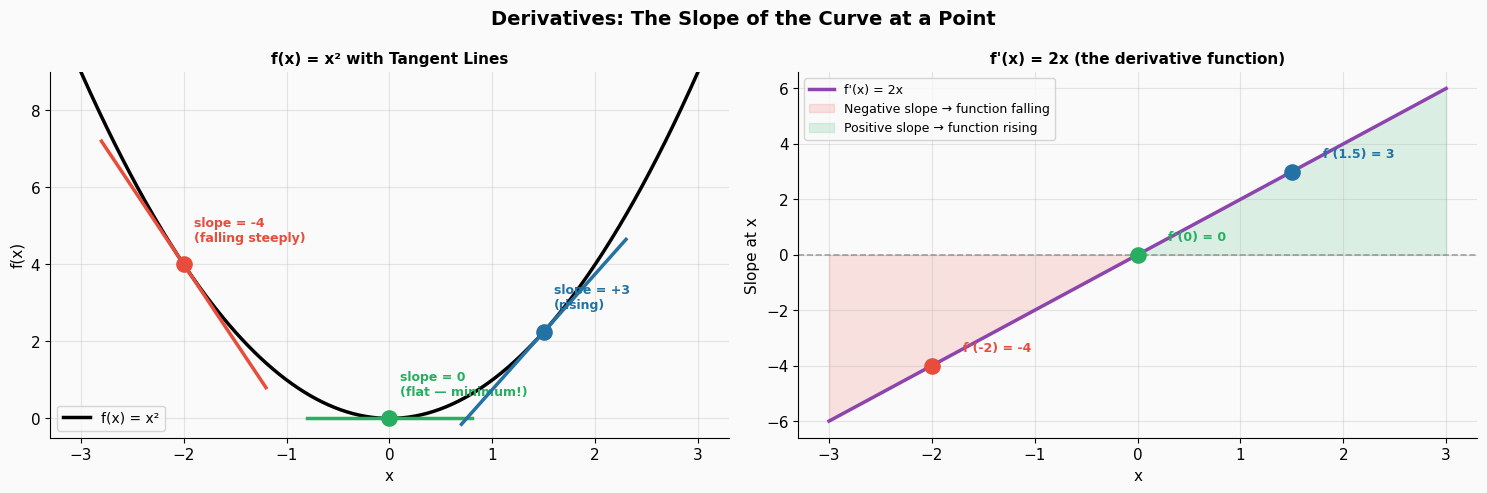

📖 Key insight: at x=0, the derivative is 0 — the curve is flat.
   This is where f(x) = x² has its MINIMUM. Gradient descent finds
   this point by following the slope downhill until derivative → 0.


In [3]:
# ─────────────────────────────────────────────────────────────────
# PART 1: VISUALISING DERIVATIVES AS SLOPES
# The speedometer analogy: same function, different instantaneous slopes
# ─────────────────────────────────────────────────────────────────

def f(x):      return x**2          # our function: a simple parabola
def f_prime(x): return 2*x          # its derivative: the slope at any point

x = np.linspace(-3, 3, 400)

# Three points where we'll show the tangent line
tangent_points = [
    (-2, '#E74C3C', 'slope = -4\n(falling steeply)'),
    ( 0, '#27AE60', 'slope = 0\n(flat — minimum!)'),
    ( 1.5, '#2471A3', 'slope = +3\n(rising)'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Derivatives: The Slope of the Curve at a Point",
             fontsize=14, fontweight='bold')

# ── Left: the function with tangent lines ─────────────────────────
ax = axes[0]
ax.plot(x, f(x), 'k-', lw=2.5, label='f(x) = x²', zorder=3)

for xp, col, label in tangent_points:
    slope = f_prime(xp)
    yp = f(xp)
    # tangent line: y = f(xp) + slope*(x - xp)
    x_tang = np.linspace(xp - 0.8, xp + 0.8, 50)
    y_tang = yp + slope * (x_tang - xp)
    ax.plot(x_tang, y_tang, color=col, lw=2.5, zorder=4)
    ax.scatter([xp], [yp], color=col, s=120, zorder=5)
    ax.text(xp + 0.1, yp + 0.6, label, color=col, fontsize=9, fontweight='bold')

ax.set_title("f(x) = x² with Tangent Lines", fontsize=11, fontweight='bold')
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 9)

# ── Right: the derivative function itself ─────────────────────────
ax2 = axes[1]
ax2.plot(x, f_prime(x), color='#8E44AD', lw=2.5, label="f'(x) = 2x")
ax2.axhline(0, color='grey', linestyle='--', lw=1.2, alpha=0.7)

for xp, col, label in tangent_points:
    ax2.scatter([xp], [f_prime(xp)], color=col, s=120, zorder=5)
    ax2.annotate(f"f'({xp}) = {f_prime(xp):.0f}",
                 xy=(xp, f_prime(xp)),
                 xytext=(xp + 0.3, f_prime(xp) + 0.5),
                 fontsize=9, color=col, fontweight='bold')

ax2.fill_between(x[x < 0], f_prime(x)[x < 0], 0, alpha=0.15, color='#E74C3C',
                 label='Negative slope → function falling')
ax2.fill_between(x[x > 0], f_prime(x)[x > 0], 0, alpha=0.15, color='#27AE60',
                 label='Positive slope → function rising')

ax2.set_title("f'(x) = 2x (the derivative function)", fontsize=11, fontweight='bold')
ax2.set_xlabel("x")
ax2.set_ylabel("Slope at x")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('derivatives_intro.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 Key insight: at x=0, the derivative is 0 — the curve is flat.")
print("   This is where f(x) = x² has its MINIMUM. Gradient descent finds")
print("   this point by following the slope downhill until derivative → 0.")

In [4]:
# ─────────────────────────────────────────────────────────────────
# NUMERICALLY VERIFYING THE DERIVATIVE DEFINITION
# Using the limit definition to approximate f'(x) at a point
# ─────────────────────────────────────────────────────────────────

def numerical_derivative(func, x, h=1e-5):
    """Approximates f'(x) using the limit definition with small h."""
    return (func(x + h) - func(x)) / h

# Test on f(x) = x² at x = 3 — exact answer is f'(3) = 2*3 = 6
x_test = 3.0
exact   = f_prime(x_test)

print("Verifying: f(x) = x²,   f'(x) = 2x,   testing at x = 3")
print(f"Exact analytic derivative:   f'(3) = {exact:.6f}")
print()
print("Numerical approximation as h shrinks:")
print(f"{'h':>12}   {'Approx f\'(3)':>16}   {'Error':>12}")
print("-" * 48)

for h in [1.0, 0.1, 0.01, 0.001, 1e-5, 1e-8]:
    approx = numerical_derivative(f, x_test, h)
    error  = abs(approx - exact)
    print(f"{h:>12.8f}   {approx:>16.8f}   {error:>12.2e}")

print()
print("📖 As h → 0, the approximation converges to the true derivative.")
print("   PyTorch's autograd does something much more elegant than this")
print("   (symbolic differentiation via the chain rule), but this shows")
print("   what the definition actually means.")

Verifying: f(x) = x²,   f'(x) = 2x,   testing at x = 3
Exact analytic derivative:   f'(3) = 6.000000

Numerical approximation as h shrinks:
           h       Approx f'(3)          Error
------------------------------------------------
  1.00000000         7.00000000       1.00e+00
  0.10000000         6.10000000       1.00e-01
  0.01000000         6.01000000       1.00e-02
  0.00100000         6.00100000       1.00e-03
  0.00001000         6.00001000       1.00e-05
  0.00000001         5.99999996       3.65e-08

📖 As h → 0, the approximation converges to the true derivative.
   PyTorch's autograd does something much more elegant than this
   (symbolic differentiation via the chain rule), but this shows
   what the definition actually means.


### 🏋️ Exercise 1.1 — Derivatives by Hand

Using the rules from Table 1.3, compute the derivative of each function:

1. **f(x) = x³** → f'(x) = ?
2. **f(x) = 5x²** → f'(x) = ?
3. **f(x) = eˣ** → f'(x) = ?
4. **f(x) = ln(x)** → f'(x) = ?

Then verify numerically using the cell below.

In [5]:
# ── Exercise 1.1 — Verify your answers numerically ────────────────
# Hint: fill in the analytic_derivative functions below and compare

test_cases = [
    ("x³",    lambda x: x**3,         lambda x: None,   2.0),  # fill None with your answer
    ("5x²",   lambda x: 5*x**2,        lambda x: None,   3.0),
    ("eˣ",    lambda x: np.exp(x),     lambda x: None,   1.0),
    ("ln(x)", lambda x: np.log(x),     lambda x: None,   2.0),
]

print("Exercise 1.1 — Verify your derivatives")
print("Replace None with your analytic answer and re-run!")
print("─" * 55)

for name, func, analytic, x_val in test_cases:
    numerical = numerical_derivative(func, x_val)
    your_answer = analytic(x_val)
    if your_answer is None:
        print(f"  f(x) = {name:8s} at x={x_val}:  numerical = {numerical:.4f}  |  yours = ???")
    else:
        match = '✅' if abs(your_answer - numerical) < 1e-3 else '❌'
        print(f"  f(x) = {name:8s} at x={x_val}:  numerical = {numerical:.4f}  |  yours = {your_answer:.4f}  {match}")

print()
print("--- SOLUTIONS (unblock when you're ready) ---")
# solutions = [3*2**2, 10*3, np.exp(1), 1/2.0]
# print(solutions)

Exercise 1.1 — Verify your derivatives
Replace None with your analytic answer and re-run!
───────────────────────────────────────────────────────
  f(x) = x³       at x=2.0:  numerical = 12.0001  |  yours = ???
  f(x) = 5x²      at x=3.0:  numerical = 30.0000  |  yours = ???
  f(x) = eˣ       at x=1.0:  numerical = 2.7183  |  yours = ???
  f(x) = ln(x)    at x=2.0:  numerical = 0.5000  |  yours = ???

--- SOLUTIONS (unblock when you're ready) ---


---
# PART 2 — Partial Derivatives

---

## 2.1 When Functions Have Many Inputs

Here's the thing about neural networks: the loss function L doesn't depend on just one weight. It depends on **millions of weights simultaneously**.

When a function takes multiple inputs, we can't ask "what is the derivative?" — we have to ask: **"how does L change when I change *this specific weight*, holding all others constant?"**

That's a **partial derivative**.

---

## 2.2 A Relatable Scenario: Room Temperature

Imagine the comfort level C of your office depends on two things:
- **T** = temperature (°C)
- **H** = humidity (%)

$$C(T, H) = -(T - 22)^2 - 0.5(H - 50)^2$$

This function is maximised (most comfortable) when T = 22°C and H = 50%.

**Partial derivative with respect to T** (holding H fixed):

$$\frac{\partial C}{\partial T} = -2(T - 22)$$

This answers: "If I change the temperature by a tiny amount, how much does comfort change?" — independent of what humidity is doing.

**Partial derivative with respect to H** (holding T fixed):

$$\frac{\partial C}{\partial H} = -(H - 50)$$

---

## 2.3 The Gradient — All Partial Derivatives Together

The **gradient** of a function is the vector of all its partial derivatives:

$$\nabla C = \left[\frac{\partial C}{\partial T}, \; \frac{\partial C}{\partial H}\right]$$

The gradient is a vector that **points in the direction of steepest ascent**.

For optimisation (minimising loss), you move in the **opposite** direction — hence **gradient *descent***: subtract the gradient from your current position.

$$\text{new position} = \text{old position} - \eta \cdot \nabla C$$

This is the weight update rule you see in every ML textbook. Now you know exactly where it comes from.

---

## 2.4 From 2 Variables to Millions

The comfort function had 2 variables. A language model has billions.

But the **logic is identical** — compute the partial derivative of the loss with respect to every single weight. That collection of partial derivatives is the gradient vector. Use it to update every weight simultaneously.

The only question is: how do you compute $\frac{\partial L}{\partial w}$ efficiently for millions of weights?

That's backpropagation. But first, we need one more tool.

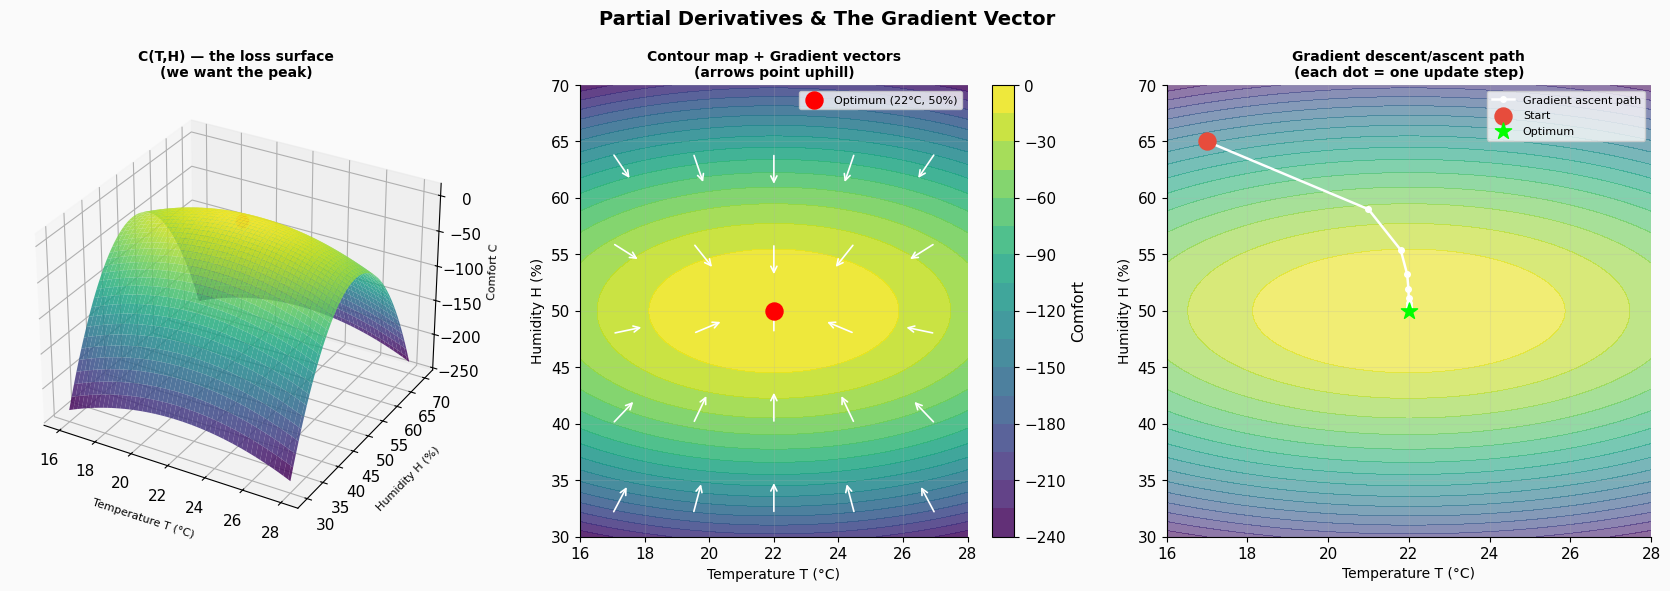

📖 The arrows always point toward the optimum — they are the gradient vectors.
   Gradient descent (for loss minimisation) just follows these arrows in REVERSE.
   Final position after 25 steps: T = 22.00°C, H = 50.00%
   Optimum:                        T = 22.00°C, H = 50.00%


In [6]:
# ─────────────────────────────────────────────────────────────────
# PART 2: PARTIAL DERIVATIVES & THE GRADIENT — 3D VISUALISATION
# The comfort function C(T, H) = -(T-22)² - 0.5*(H-50)²
# ─────────────────────────────────────────────────────────────────

def comfort(T, H):
    return -(T - 22)**2 - 0.5*(H - 50)**2

def dC_dT(T, H):
    return -2*(T - 22)            # partial w.r.t. temperature

def dC_dH(T, H):
    return -(H - 50)              # partial w.r.t. humidity

T_range = np.linspace(16, 28, 100)
H_range = np.linspace(30, 70, 100)
T_grid, H_grid = np.meshgrid(T_range, H_range)
C_grid = comfort(T_grid, H_grid)

fig = plt.figure(figsize=(17, 6))
fig.suptitle("Partial Derivatives & The Gradient Vector", fontsize=14, fontweight='bold')

# ── Plot 1: 3D surface ────────────────────────────────────────────
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(T_grid, H_grid, C_grid, cmap='viridis', alpha=0.85)
ax1.set_xlabel('Temperature T (°C)', fontsize=8, labelpad=6)
ax1.set_ylabel('Humidity H (%)', fontsize=8, labelpad=6)
ax1.set_zlabel('Comfort C', fontsize=8)
ax1.set_title('C(T,H) — the loss surface\n(we want the peak)', fontsize=10, fontweight='bold')
ax1.scatter([22], [50], [comfort(22,50)], color='red', s=80, zorder=5)
ax1.text(22, 50, comfort(22,50)+300, 'Optimum!', color='red', fontsize=8, fontweight='bold')

# ── Plot 2: Contour map + gradient arrows ────────────────────────
ax2 = fig.add_subplot(132)
cp = ax2.contourf(T_grid, H_grid, C_grid, levels=20, cmap='viridis', alpha=0.85)
plt.colorbar(cp, ax=ax2, label='Comfort')

# Draw gradient arrows at a grid of points
T_pts = np.arange(17, 28, 2.5)
H_pts = np.arange(32, 70, 8)
for t in T_pts:
    for h in H_pts:
        grad_t = dC_dT(t, h)
        grad_h = dC_dH(t, h)
        norm = np.sqrt(grad_t**2 + grad_h**2) + 1e-8
        ax2.annotate("", xy=(t + grad_t/norm*1.0, h + grad_h/norm*3.0),
                     xytext=(t, h),
                     arrowprops=dict(arrowstyle='->', color='white', lw=1.2))

ax2.scatter([22], [50], color='red', s=150, zorder=5, label='Optimum (22°C, 50%)')
ax2.set_xlabel('Temperature T (°C)', fontsize=10)
ax2.set_ylabel('Humidity H (%)', fontsize=10)
ax2.set_title('Contour map + Gradient vectors\n(arrows point uphill)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.2)

# ── Plot 3: Gradient descent path ────────────────────────────────
ax3 = fig.add_subplot(133)
ax3.contourf(T_grid, H_grid, C_grid, levels=20, cmap='viridis', alpha=0.6)

# Simulate gradient ASCENT from a bad starting point
T_curr, H_curr = 17.0, 65.0
lr = 0.4
path_T, path_H = [T_curr], [H_curr]

for _ in range(25):
    T_curr += lr * dC_dT(T_curr, H_curr)   # ascent: + gradient
    H_curr += lr * dC_dH(T_curr, H_curr)
    path_T.append(T_curr)
    path_H.append(H_curr)

ax3.plot(path_T, path_H, 'w-o', markersize=4, lw=1.8, label='Gradient ascent path')
ax3.scatter([path_T[0]], [path_H[0]], color='#E74C3C', s=150, zorder=6, label='Start')
ax3.scatter([22], [50], color='lime', s=150, zorder=6, marker='*', label='Optimum')
ax3.set_xlabel('Temperature T (°C)', fontsize=10)
ax3.set_ylabel('Humidity H (%)', fontsize=10)
ax3.set_title('Gradient descent/ascent path\n(each dot = one update step)', fontsize=10, fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('partial_derivatives.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 The arrows always point toward the optimum — they are the gradient vectors.")
print("   Gradient descent (for loss minimisation) just follows these arrows in REVERSE.")
print(f"   Final position after 25 steps: T = {path_T[-1]:.2f}°C, H = {path_H[-1]:.2f}%")
print(f"   Optimum:                        T = 22.00°C, H = 50.00%")

### 🏋️ Exercise 2.1 — Partial Derivatives

Consider the function:

$$f(x, y) = 3x^2 + 2xy + y^2$$

1. Compute $\frac{\partial f}{\partial x}$ — treat y as a constant
2. Compute $\frac{\partial f}{\partial y}$ — treat x as a constant
3. At the point (x=1, y=2), what is the gradient vector $\nabla f$?
4. What direction should you move to *decrease* f most quickly from that point?

In [7]:
# ── Exercise 2.1 — Verify your partial derivatives ────────────────

def f_ex(x, y):   return 3*x**2 + 2*x*y + y**2

x0, y0 = 1.0, 2.0

# Numerical partials (using finite differences)
h = 1e-6
numerical_df_dx = (f_ex(x0+h, y0) - f_ex(x0, y0)) / h
numerical_df_dy = (f_ex(x0, y0+h) - f_ex(x0, y0)) / h

print("f(x, y) = 3x² + 2xy + y²   at (x=1, y=2)")
print()
print(f"Numerical ∂f/∂x = {numerical_df_dx:.4f}")
print(f"Numerical ∂f/∂y = {numerical_df_dy:.4f}")
print()

# ── Fill in YOUR analytic answers here ───────────────────────────
your_df_dx = None   # e.g. 6*x0 + 2*y0
your_df_dy = None   # e.g. ...

if your_df_dx is not None:
    match_x = '✅' if abs(your_df_dx - numerical_df_dx) < 1e-3 else '❌'
    match_y = '✅' if abs(your_df_dy - numerical_df_dy) < 1e-3 else '❌'
    print(f"Your ∂f/∂x = {your_df_dx:.4f}  {match_x}")
    print(f"Your ∂f/∂y = {your_df_dy:.4f}  {match_y}")
else:
    print("Replace None above with your computed answers to check!")

print()
print("--- SOLUTIONS (unblock when ready) ---")
# ∂f/∂x = 6x + 2y  → at (1,2): 6*1 + 2*2 = 10
# ∂f/∂y = 2x + 2y  → at (1,2): 2*1 + 2*2 = 6
# gradient = [10, 6]   → to DECREASE f, move in direction [-10, -6]

f(x, y) = 3x² + 2xy + y²   at (x=1, y=2)

Numerical ∂f/∂x = 10.0000
Numerical ∂f/∂y = 6.0000

Replace None above with your computed answers to check!

--- SOLUTIONS (unblock when ready) ---


---
# PART 3 — The Chain Rule

---

## 3.1 The Single Most Important Rule in All of Deep Learning

If there is one concept in this entire notebook that you must truly understand, it's this one.

**The chain rule** tells you how to differentiate **composed functions** — functions built by plugging one function into another.

Neural networks are *nothing but* composed functions. Input → linear layer → activation → linear layer → activation → loss. Every arrow is a function composition.

---

## 3.2 A Real-World Chain: The Coffee Shop Scenario

You manage a coffee shop. Your monthly profit **P** depends on how many cups you sell **S**. The number of cups sold depends on the price you charge **p**.

- **S(p)**: Sales as a function of price. Lower price → more sales. Say S(p) = 1000 - 50p
- **P(S)**: Profit as a function of sales. P(S) = 3S - 2000 (3 UGX profit per cup, 2000 fixed cost)

You want to know: **if I raise the price by 1 UGX, how does my profit change?**

That's $\frac{dP}{dp}$ — but P doesn't directly depend on p! It depends on S, which depends on p.

**The Chain Rule says:**

$$\frac{dP}{dp} = \frac{dP}{dS} \cdot \frac{dS}{dp}$$

"How does profit change with price" = "How does profit change with sales" × "How does sales change with price"

Let's compute:
- $\frac{dP}{dS} = 3$ (each extra cup sold adds 3 to profit)
- $\frac{dS}{dp} = -50$ (each 1 UGX price increase loses 50 sales)
- $\frac{dP}{dp} = 3 \times (-50) = -150$

Raising price by 1 UGX decreases profit by 150 UGX. The chain rule traced the effect through the intermediate variable S.

---

## 3.3 Formal Statement

If $y = f(g(x))$, then:

$$\frac{dy}{dx} = \frac{dy}{dg} \cdot \frac{dg}{dx} = f'(g(x)) \cdot g'(x)$$

With more intermediate steps — say $y = f(g(h(x)))$:

$$\frac{dy}{dx} = \frac{dy}{df} \cdot \frac{df}{dg} \cdot \frac{dg}{dx}$$

You multiply the derivatives through the chain, one link at a time.

---

## 3.4 Why This Is Backpropagation

Consider a tiny network with two layers and a loss:

$$x \xrightarrow{w_1} z_1 = w_1 x \xrightarrow{\text{ReLU}} a_1 = \text{ReLU}(z_1) \xrightarrow{w_2} z_2 = w_2 a_1 \xrightarrow{\text{loss}} L = (z_2 - y)^2$$

We want $\frac{\partial L}{\partial w_1}$. But L doesn't directly mention w₁! We need the chain rule:

$$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial z_2} \cdot \frac{\partial z_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial w_1}$$

That's **four terms multiplied together** — one for each arrow in the chain. Backpropagation is literally just evaluating this product, **starting from the loss and working backwards**.

"Back" in backpropagation = backwards through the chain rule.

In [8]:
# ─────────────────────────────────────────────────────────────────
# PART 3: THE CHAIN RULE — VISUALISING GRADIENT FLOW
# We trace how a small change in w1 propagates through the network
# ─────────────────────────────────────────────────────────────────

# ── Forward pass setup ───────────────────────────────────────────
x  = 2.0   # input
y  = 1.0   # true label
w1 = 0.5   # weight in layer 1
w2 = 1.2   # weight in layer 2

# Forward pass: compute every intermediate value
z1 = w1 * x                          # linear step 1
a1 = max(0, z1)                       # ReLU activation
z2 = w2 * a1                          # linear step 2
L  = (z2 - y)**2                      # MSE loss

print("=" * 55)
print("FORWARD PASS — computing intermediate values")
print("=" * 55)
print(f"  Input:           x  = {x}")
print(f"  True label:      y  = {y}")
print()
print(f"  z1 = w1 * x    = {w1} * {x} = {z1}")
print(f"  a1 = ReLU(z1)  = max(0, {z1}) = {a1}")
print(f"  z2 = w2 * a1   = {w2} * {a1} = {z2:.4f}")
print(f"  L  = (z2-y)²   = ({z2:.4f} - {y})² = {L:.4f}")
print()

# ── Backward pass: chain rule step by step ───────────────────────
print("=" * 55)
print("BACKWARD PASS — applying the chain rule")
print("=" * 55)
print()
print("We want ∂L/∂w1. Chain rule expands it as:")
print("  ∂L/∂w1 = (∂L/∂z2) · (∂z2/∂a1) · (∂a1/∂z1) · (∂z1/∂w1)")
print()

dL_dz2 = 2 * (z2 - y)                # derivative of (z2-y)² w.r.t. z2
dz2_da1 = w2                          # derivative of w2*a1 w.r.t. a1
da1_dz1 = 1.0 if z1 > 0 else 0.0    # derivative of ReLU: 1 if positive, 0 if negative
dz1_dw1 = x                           # derivative of w1*x w.r.t. w1

dL_dw1 = dL_dz2 * dz2_da1 * da1_dz1 * dz1_dw1
dL_dw2 = dL_dz2 * a1                  # also need this for completeness

print(f"  ∂L/∂z2  = 2*(z2-y)       = 2*({z2:.4f}-{y}) = {dL_dz2:.4f}")
print(f"  ∂z2/∂a1 = w2              = {dz2_da1}")
print(f"  ∂a1/∂z1 = ReLU'(z1)      = {da1_dz1}  (z1={z1} > 0, so gradient passes through)")
print(f"  ∂z1/∂w1 = x               = {dz1_dw1}")
print()
print(f"  ∂L/∂w1 = {dL_dz2:.4f} × {dz2_da1} × {da1_dz1} × {dz1_dw1} = {dL_dw1:.4f}")
print(f"  ∂L/∂w2 = {dL_dz2:.4f} × {a1} = {dL_dw2:.4f}")
print()

# ── Numerical verification ────────────────────────────────────────
def forward(w1_, w2_):
    z1_ = w1_ * x
    a1_ = max(0, z1_)
    z2_ = w2_ * a1_
    return (z2_ - y)**2

h = 1e-5
numerical_dw1 = (forward(w1+h, w2) - forward(w1, w2)) / h
numerical_dw2 = (forward(w1, w2+h) - forward(w1, w2)) / h

print("Numerical verification (finite differences):")
print(f"  ∂L/∂w1 numerical: {numerical_dw1:.4f}  vs chain rule: {dL_dw1:.4f}  {'✅' if abs(numerical_dw1-dL_dw1)<1e-3 else '❌'}")
print(f"  ∂L/∂w2 numerical: {numerical_dw2:.4f}  vs chain rule: {dL_dw2:.4f}  {'✅' if abs(numerical_dw2-dL_dw2)<1e-3 else '❌'}")

FORWARD PASS — computing intermediate values
  Input:           x  = 2.0
  True label:      y  = 1.0

  z1 = w1 * x    = 0.5 * 2.0 = 1.0
  a1 = ReLU(z1)  = max(0, 1.0) = 1.0
  z2 = w2 * a1   = 1.2 * 1.0 = 1.2000
  L  = (z2-y)²   = (1.2000 - 1.0)² = 0.0400

BACKWARD PASS — applying the chain rule

We want ∂L/∂w1. Chain rule expands it as:
  ∂L/∂w1 = (∂L/∂z2) · (∂z2/∂a1) · (∂a1/∂z1) · (∂z1/∂w1)

  ∂L/∂z2  = 2*(z2-y)       = 2*(1.2000-1.0) = 0.4000
  ∂z2/∂a1 = w2              = 1.2
  ∂a1/∂z1 = ReLU'(z1)      = 1.0  (z1=1.0 > 0, so gradient passes through)
  ∂z1/∂w1 = x               = 2.0

  ∂L/∂w1 = 0.4000 × 1.2 × 1.0 × 2.0 = 0.9600
  ∂L/∂w2 = 0.4000 × 1.0 = 0.4000

Numerical verification (finite differences):
  ∂L/∂w1 numerical: 0.9601  vs chain rule: 0.9600  ✅
  ∂L/∂w2 numerical: 0.4000  vs chain rule: 0.4000  ✅


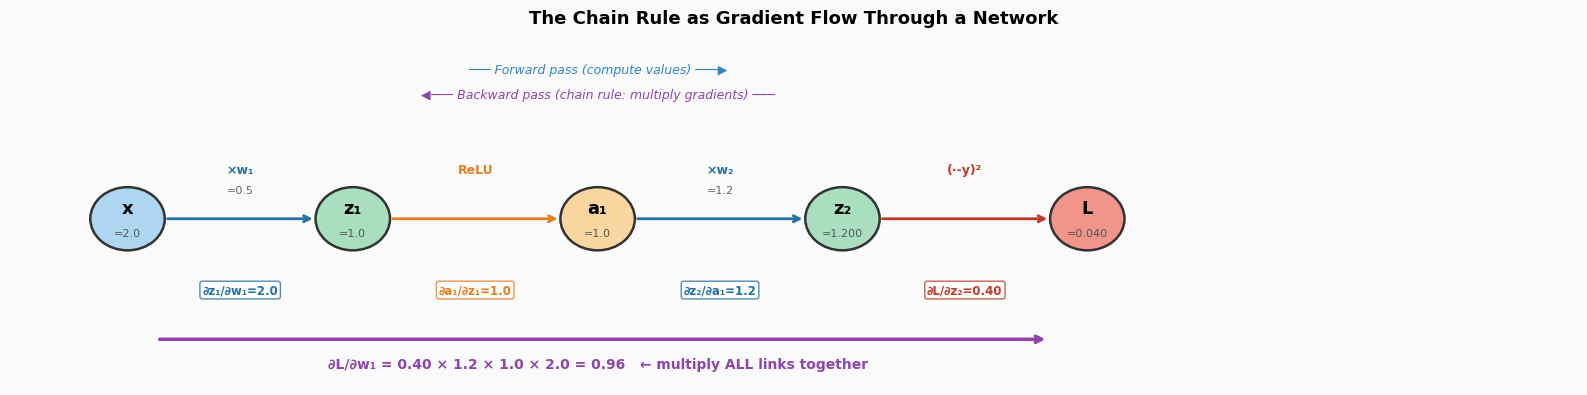

📖 Backpropagation is just this diagram, applied to millions of nodes.
   Each node stores its local gradient. The chain rule multiplies them backward.


In [9]:
# ─────────────────────────────────────────────────────────────────
# VISUALISING THE CHAIN RULE AS GRADIENT FLOW
# ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 16)
ax.set_ylim(0, 4)
ax.axis('off')
ax.set_facecolor('#FAFAFA')
fig.suptitle("The Chain Rule as Gradient Flow Through a Network",
             fontsize=13, fontweight='bold')

# Node definitions: (x, y, label, sublabel, colour)
nodes = [
    (1.2, 2.0, "x",  f"={x}",      '#AED6F1'),
    (3.5, 2.0, "z₁", f"={z1}",     '#A9DFBF'),
    (6.0, 2.0, "a₁", f"={a1}",     '#FAD7A0'),
    (8.5, 2.0, "z₂", f"={z2:.3f}", '#A9DFBF'),
    (11.0,2.0, "L",  f"={L:.3f}",  '#F1948A'),
]

edges_fwd = [
    (1.2, 3.5, "×w₁", f"={w1}",    '#2471A3'),
    (3.5, 6.0, "ReLU", "",          '#E67E22'),
    (6.0, 8.5, "×w₂", f"={w2}",    '#2471A3'),
    (8.5, 11.0,"(·-y)²", "",        '#C0392B'),
]

grad_labels = [
    (2.35, 1.1, f"∂z₁/∂w₁={dz1_dw1:.1f}", '#2471A3'),
    (4.75, 1.1, f"∂a₁/∂z₁={da1_dz1:.1f}", '#E67E22'),
    (7.25, 1.1, f"∂z₂/∂a₁={dz2_da1:.1f}", '#2471A3'),
    (9.75, 1.1, f"∂L/∂z₂={dL_dz2:.2f}",   '#C0392B'),
]

r = 0.38
for (xi, yi, lbl, sub, col) in nodes:
    circle = plt.Circle((xi, yi), r, color=col, ec='#333', lw=1.8, zorder=3)
    ax.add_patch(circle)
    ax.text(xi, yi+0.12, lbl, ha='center', va='center', fontsize=13,
            fontweight='bold', zorder=4)
    ax.text(xi, yi-0.18, sub, ha='center', va='center', fontsize=8,
            color='#555', zorder=4)

for (x1, x2, op, val, col) in edges_fwd:
    ax.annotate("", xy=(x2-r, 2.0), xytext=(x1+r, 2.0),
                arrowprops=dict(arrowstyle='->', color=col, lw=2.0))
    mid = (x1+x2)/2
    ax.text(mid, 2.55, op, ha='center', fontsize=9, color=col, fontweight='bold')
    ax.text(mid, 2.3, val, ha='center', fontsize=8, color='#666')

for (xg, yg, lbl, col) in grad_labels:
    ax.text(xg, yg, lbl, ha='center', fontsize=8.5, color=col, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=col, alpha=0.8))

ax.annotate("", xy=(1.5, 0.55), xytext=(10.6, 0.55),
            arrowprops=dict(arrowstyle='<-', color='#8E44AD', lw=2.5))
ax.text(6.0, 0.2, f"∂L/∂w₁ = {dL_dz2:.2f} × {dz2_da1} × {da1_dz1} × {dz1_dw1} = {dL_dw1:.2f}   ← multiply ALL links together",
        ha='center', fontsize=10, color='#8E44AD', fontweight='bold')

ax.text(6.0, 3.75, '─── Forward pass (compute values) ───▶', ha='center',
        fontsize=9, color='#2E86C1', style='italic')
ax.text(6.0, 3.45, '◀─── Backward pass (chain rule: multiply gradients) ───', ha='center',
        fontsize=9, color='#8E44AD', style='italic')

plt.tight_layout()
plt.savefig('chain_rule_flow.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 Backpropagation is just this diagram, applied to millions of nodes.")
print("   Each node stores its local gradient. The chain rule multiplies them backward.")

### 🏋️ Exercise 3.1 — Tracing the Chain Rule

Given the tiny network below:

$$x = 3, \quad w = 0.4, \quad b = 0.1, \quad y_{\text{true}} = 2$$

$$z = wx + b \quad \rightarrow \quad \hat{y} = \sigma(z) = \frac{1}{1+e^{-z}} \quad \rightarrow \quad L = (\hat{y} - y)^2$$

1. Compute the forward pass: z, ŷ, L
2. Compute $\frac{\partial L}{\partial \hat{y}}$ (hint: derivative of squared error)
3. Compute $\frac{\partial \hat{y}}{\partial z}$ (hint: sigmoid derivative is σ(z)·(1-σ(z)))
4. Compute $\frac{\partial z}{\partial w}$ and $\frac{\partial z}{\partial b}$
5. Chain them together: $\frac{\partial L}{\partial w}$ and $\frac{\partial L}{\partial b}$

In [10]:
# ── Exercise 3.1 — Chain rule through sigmoid ─────────────────────
x_ex, w_ex, b_ex, y_ex = 3.0, 0.4, 0.1, 2.0

# ── Your forward pass (fill these in) ────────────────────────────
z_ex   = None   # w*x + b
y_hat  = None   # sigmoid(z)
L_ex   = None   # (y_hat - y)^2

# ── Your backward pass (fill these in) ───────────────────────────
dL_dyhat  = None   # ∂L/∂ŷ
dyhat_dz  = None   # ∂ŷ/∂z  (sigmoid gradient)
dz_dw     = None   # ∂z/∂w
dz_db     = None   # ∂z/∂b

dL_dw_ex  = None   # final answer: chain them together
dL_db_ex  = None

# ── Numerical verification ────────────────────────────────────────
def forward_ex(w_, b_):
    z_ = w_*x_ex + b_
    yh = 1/(1+np.exp(-z_))
    return (yh - y_ex)**2

h = 1e-6
num_dw = (forward_ex(w_ex+h, b_ex) - forward_ex(w_ex, b_ex)) / h
num_db = (forward_ex(w_ex, b_ex+h) - forward_ex(w_ex, b_ex)) / h

print(f"Numerical ∂L/∂w = {num_dw:.6f}")
print(f"Numerical ∂L/∂b = {num_db:.6f}")
print()
if dL_dw_ex is not None:
    print(f"Your    ∂L/∂w = {dL_dw_ex:.6f}  {'✅' if abs(dL_dw_ex - num_dw) < 1e-3 else '❌'}")
    print(f"Your    ∂L/∂b = {dL_db_ex:.6f}  {'✅' if abs(dL_db_ex - num_db) < 1e-3 else '❌'}")
else:
    print("Fill in the None values above and re-run!")

print()
print("--- SOLUTIONS ---")
# z = 0.4*3 + 0.1 = 1.3
# y_hat = sigmoid(1.3) ≈ 0.7858
# L = (0.7858 - 2)^2 ≈ 1.474
# dL/dyhat = 2*(yhat-y) ≈ -2.4284
# dyhat/dz = yhat*(1-yhat) ≈ 0.1685
# dz/dw = x = 3,   dz/db = 1
# dL/dw = -2.4284 * 0.1685 * 3 ≈ -1.227
# dL/db = -2.4284 * 0.1685 * 1 ≈ -0.409

Numerical ∂L/∂w = -1.226051
Numerical ∂L/∂b = -0.408684

Fill in the None values above and re-run!

--- SOLUTIONS ---


---
# PART 4 — The Computational Graph

---

## 4.1 What Is a Computational Graph?

A **computational graph** is a way of representing a mathematical expression as a directed graph (a network of nodes and arrows).

Every **node** is either:
- An **input** (a variable like x, w, or b)
- An **operation** (like multiply, add, square, sigmoid)

Every **edge** (arrow) carries a value from one node to the next.

When you write `loss.backward()` in PyTorch, you're telling it: **"traverse this graph backwards and apply the chain rule at every node."**

---

## 4.2 Why Graphs? Two Key Reasons

**Reason 1: Modular differentiation.** Every operation node only needs to know its own local gradient. It doesn't need to know what's happening elsewhere. This makes the system scalable to any architecture.

**Reason 2: Efficient reuse.** During forward pass, we store intermediate values at each node. During backward pass, we reuse those stored values to compute gradients efficiently — no recomputing.

---

## 4.3 Dynamic vs Static Graphs

| Feature | PyTorch (Dynamic) | TensorFlow 1.x (Static) |
|:--------|:-----------------:|:------------------------:|
| Graph built | At runtime, on every forward pass | Once, before training |
| Debugging | Easy — just use Python debugger | Hard — graph is compiled |
| Flexibility | High — can change per input | Lower |
| Speed | Slightly slower (more overhead) | Slightly faster (optimised) |

PyTorch's dynamic graphs are one reason it became the research standard — you can write normal Python code and it just works.

---

## 4.4 Every Node's Job

In a computational graph, each operation node has exactly two responsibilities:

1. **Forward:** Take inputs, compute output
2. **Backward:** Take the gradient arriving from above (∂L/∂output), multiply by local gradient, pass it to inputs below

This is called the **local gradient** pattern. Every node is responsible for one small computation. Backpropagation is just the orchestration of these local computations.

In [11]:
# ─────────────────────────────────────────────────────────────────
# PART 4: BUILDING A MINIMAL COMPUTATIONAL GRAPH FROM SCRATCH
# This is a simplified version of what PyTorch's autograd does.
# ─────────────────────────────────────────────────────────────────

class Value:
    """
    A scalar value in a computational graph.
    Tracks the operation that created it and its input nodes.
    Supports forward computation and backward gradient accumulation.
    
    This is a simplified version of PyTorch's Tensor.
    """
    def __init__(self, data, _children=(), _op='', label=''):
        self.data     = data
        self.grad     = 0.0          # starts at zero; backprop fills this in
        self._backward = lambda: None  # will be set by operations
        self._prev    = set(_children)
        self._op      = _op
        self.label    = label

    def __add__(self, other):
        """Addition node: output = self + other"""
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            # Gradient of addition flows through unchanged to both inputs
            self.grad  += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        """Multiply node: output = self * other. Gradients are SWAPPED."""
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            # Chain rule for multiply: ∂(a*b)/∂a = b, ∂(a*b)/∂b = a
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def relu(self):
        """ReLU node: output = max(0, self)"""
        out = Value(max(0, self.data), (self,), 'ReLU')
        def _backward():
            # Gradient passes through only if input was positive
            self.grad += (self.data > 0) * out.grad
        out._backward = _backward
        return out

    def square_loss(self, target):
        """MSE loss node: L = (self - target)²"""
        diff = self.data - target
        out = Value(diff**2, (self,), '(·-y)²')
        def _backward():
            self.grad += 2 * diff * out.grad
        out._backward = _backward
        return out

    def backward(self):
        """Topological sort + backward pass (the actual backprop)."""
        topo, visited = [], set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0   # dL/dL = 1 always
        for node in reversed(topo):
            node._backward()

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f}, op='{self._op}')"


# ── Build and run the same network as Part 3 ─────────────────────
print("Building computational graph: x → z1 = w1*x → a1 = ReLU → z2 = w2*a1 → L")
print()

x_v  = Value(2.0,  label='x')
w1_v = Value(0.5,  label='w1')
w2_v = Value(1.2,  label='w2')

z1_v = w1_v * x_v;          z1_v.label = 'z1'
a1_v = z1_v.relu();          a1_v.label = 'a1'
z2_v = w2_v * a1_v;          z2_v.label = 'z2'
L_v  = z2_v.square_loss(1.0); L_v.label = 'L'

print("Forward pass:")
for node in [z1_v, a1_v, z2_v, L_v]:
    print(f"  {node.label:4s} = {node.data:.4f}")

# Run backprop
L_v.backward()

print()
print("Backward pass (gradients):")
for node, name in [(w1_v,'w1'), (w2_v,'w2'), (x_v,'x')]:
    print(f"  ∂L/∂{name:2s} = {node.grad:.4f}")

print()
print(f"Manual chain rule ∂L/∂w1: {dL_dw1:.4f}")
print(f"Graph autograd  ∂L/∂w1: {w1_v.grad:.4f}")
print(f"Match: {'✅' if abs(w1_v.grad - dL_dw1) < 1e-6 else '❌'}")

Building computational graph: x → z1 = w1*x → a1 = ReLU → z2 = w2*a1 → L

Forward pass:
  z1   = 1.0000
  a1   = 1.0000
  z2   = 1.2000
  L    = 0.0400

Backward pass (gradients):
  ∂L/∂w1 = 0.9600
  ∂L/∂w2 = 0.4000
  ∂L/∂x  = 0.2400

Manual chain rule ∂L/∂w1: 0.9600
Graph autograd  ∂L/∂w1: 0.9600
Match: ✅


---
# PART 5 — Jacobians

---

## 5.1 When Both Input and Output Are Vectors

So far, we've differentiated functions with scalar (single-number) outputs. But in neural networks, most operations transform **vectors into vectors**.

A layer with 128 input neurons and 64 output neurons takes a vector of length 128 and produces a vector of length 64. How do you differentiate that?

The answer is a **Jacobian matrix**.

---

## 5.2 What Is a Jacobian?

If a function maps $\mathbf{x} \in \mathbb{R}^n \rightarrow \mathbf{y} \in \mathbb{R}^m$, the **Jacobian** is the matrix of all first-order partial derivatives:

$$J = \frac{\partial \mathbf{y}}{\partial \mathbf{x}} = 
\begin{bmatrix}
\frac{\partial y_1}{\partial x_1} & \frac{\partial y_1}{\partial x_2} & \cdots & \frac{\partial y_1}{\partial x_n} \\
\frac{\partial y_2}{\partial x_1} & \frac{\partial y_2}{\partial x_2} & \cdots & \frac{\partial y_2}{\partial x_n} \\
\vdots & & \ddots & \vdots \\
\frac{\partial y_m}{\partial x_1} & \frac{\partial y_m}{\partial x_2} & \cdots & \frac{\partial y_m}{\partial x_n}
\end{bmatrix}$$

Each row i tells you: "how does output $y_i$ change as each input $x_j$ varies?"

The Jacobian has shape **(m × n)** — one row per output, one column per input.

---

## 5.3 The Jacobian of a Linear Layer

For the operation $\mathbf{y} = W\mathbf{x}$ (a linear layer with weight matrix W):

$$J = \frac{\partial \mathbf{y}}{\partial \mathbf{x}} = W$$

The Jacobian of a linear layer **is just the weight matrix itself**. This is why matrix operations dominate neural network gradients.

For the gradient of the loss with respect to x: $\frac{\partial L}{\partial \mathbf{x}} = W^T \frac{\partial L}{\partial \mathbf{y}}$

That transposition is why you see Wᵀ everywhere in backpropagation derivations.

---

## 5.4 When Jacobians Are Diagonal (Element-wise Operations)

For element-wise operations like ReLU applied to a vector — each output $y_i$ depends *only* on the corresponding input $x_i$:

$$J_{\text{ReLU}} = \text{diag}(\mathbb{1}[x_i > 0]) = 
\begin{bmatrix}
\mathbb{1}[x_1>0] & 0 & 0 \\
0 & \mathbb{1}[x_2>0] & 0 \\
0 & 0 & \mathbb{1}[x_3>0]
\end{bmatrix}$$

The off-diagonal entries are all zero. This is why element-wise operations are so computationally cheap to backpropagate through — the Jacobian is just a mask.

---

## 5.5 Why Frontier Labs Don't Compute Full Jacobians

For a layer with 4096 inputs and 4096 outputs, the full Jacobian would be a 4096×4096 matrix — 16 million numbers. Computing this explicitly is almost never done.

Instead, deep learning frameworks use **vector-Jacobian products (VJPs)**: given the incoming gradient vector $\mathbf{v}$, compute $\mathbf{v}^T J$ without materialising J. This is the key efficiency trick that makes backprop tractable at scale.

Weight matrix W:
[[2 1 0]
 [0 3 1]
 [1 0 2]]

Jacobian of linear layer y=Wx (should equal W):
[[2. 1. 0.]
 [0. 3. 1.]
 [1. 0. 2.]]
  J = W? True ✅

Input x = [1. 2. 3.]
ReLU(x) = [1. 2. 3.]
Jacobian of ReLU (should be diagonal mask):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
  Off-diagonal entries are zero (ReLU is element-wise) ✅


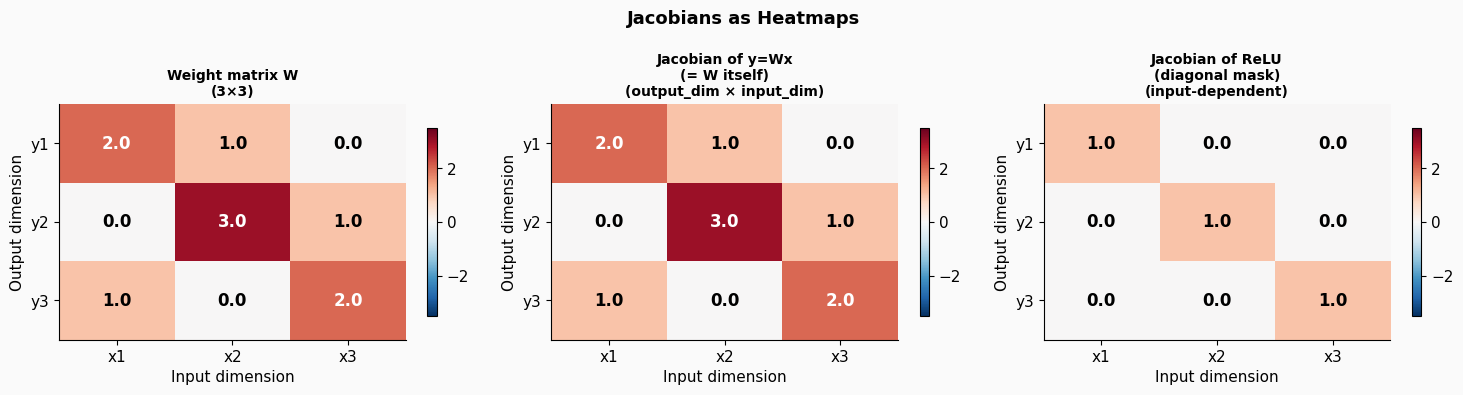

📖 The Jacobian of a linear layer is the weight matrix itself.
   The Jacobian of ReLU is a diagonal matrix of 0s and 1s.
   In backprop, multiplying by these Jacobians IS the gradient computation.


In [12]:
# ─────────────────────────────────────────────────────────────────
# PART 5: JACOBIANS — COMPUTING AND VISUALISING
# ─────────────────────────────────────────────────────────────────

def compute_jacobian(func, x, output_size):
    """
    Numerically compute the Jacobian of func at x using finite differences.
    func:  R^n → R^m
    x:     input vector (length n)
    Returns: J of shape (m, n)
    """
    n = len(x)
    J = np.zeros((output_size, n))
    h = 1e-5
    for j in range(n):
        x_plus  = x.copy(); x_plus[j]  += h
        x_minus = x.copy(); x_minus[j] -= h
        J[:, j] = (func(x_plus) - func(x_minus)) / (2*h)
    return J


# ── Example 1: Linear layer y = Wx ────────────────────────────────
np.random.seed(42)
W = np.array([[2, 1, 0],
              [0, 3, 1],
              [1, 0, 2]])
x_in = np.array([1.0, 2.0, 3.0])

def linear_layer(x): return W @ x
def relu_layer(x):   return np.maximum(0, x)

J_linear = compute_jacobian(linear_layer, x_in, 3)
J_relu   = compute_jacobian(relu_layer,   x_in, 3)

print("Weight matrix W:")
print(W)
print()
print("Jacobian of linear layer y=Wx (should equal W):")
print(J_linear.round(4))
print(f"  J = W? {np.allclose(J_linear, W)} ✅" if np.allclose(J_linear, W) else "Mismatch")

print()
print(f"Input x = {x_in}")
print(f"ReLU(x) = {relu_layer(x_in)}")
print("Jacobian of ReLU (should be diagonal mask):")
print(J_relu.round(4))
print("  Off-diagonal entries are zero (ReLU is element-wise) ✅")


# ── Visualise both Jacobians as heatmaps ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Jacobians as Heatmaps", fontsize=13, fontweight='bold')

matrices_to_plot = [
    (W,        "Weight matrix W",              "(3×3)"),
    (J_linear, "Jacobian of y=Wx\n(= W itself)",  "(output_dim × input_dim)"),
    (J_relu,   "Jacobian of ReLU\n(diagonal mask)","(input-dependent)"),
]

for ax, (mat, title, sub) in zip(axes, matrices_to_plot):
    im = ax.imshow(mat, cmap='RdBu_r', aspect='auto',
                   vmin=-3.5, vmax=3.5)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i,j]:.1f}", ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='white' if abs(mat[i,j]) > 1.5 else 'black')
    ax.set_title(f"{title}\n{sub}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Input dimension")
    ax.set_ylabel("Output dimension")
    n_out, n_in = mat.shape
    ax.set_xticks(range(n_in));  ax.set_xticklabels([f'x{i+1}' for i in range(n_in)])
    ax.set_yticks(range(n_out)); ax.set_yticklabels([f'y{i+1}' for i in range(n_out)])

plt.tight_layout()
plt.savefig('jacobians.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 The Jacobian of a linear layer is the weight matrix itself.")
print("   The Jacobian of ReLU is a diagonal matrix of 0s and 1s.")
print("   In backprop, multiplying by these Jacobians IS the gradient computation.")

### 🏋️ Exercise 5.1 — Building Intuition for Jacobians

Consider the function $f: \mathbb{R}^2 \rightarrow \mathbb{R}^2$ defined as:

$$f(x_1, x_2) = \begin{pmatrix} x_1^2 + x_2 \\ 3x_1 - x_2^2 \end{pmatrix}$$

1. Write out the full 2×2 Jacobian matrix analytically
2. At the point (x₁=2, x₂=1), evaluate the Jacobian numerically
3. What does the entry J[0,1] tell you? (hint: which output changes when x₂ changes?)

In [13]:
# ── Exercise 5.1 — Jacobian of a nonlinear function ───────────────

def f_vec(x):
    return np.array([
        x[0]**2 + x[1],
        3*x[0] - x[1]**2
    ])

x_eval = np.array([2.0, 1.0])

# Numerical Jacobian
J_numerical = compute_jacobian(f_vec, x_eval, output_size=2)
print("Numerical Jacobian at (x1=2, x2=1):")
print(J_numerical.round(4))
print()

# ── Fill in your analytic Jacobian ───────────────────────────────
# J[i,j] = ∂f_i/∂x_j
x1, x2 = x_eval

J_analytic = np.array([
    [None, None],   # [∂f1/∂x1, ∂f1/∂x2]
    [None, None],   # [∂f2/∂x1, ∂f2/∂x2]
])

if J_analytic[0,0] is not None:
    print("Your analytic Jacobian:")
    print(J_analytic)
    print("Match:", np.allclose(J_analytic, J_numerical, atol=1e-3))
else:
    print("Fill in J_analytic above and re-run!")

print()
print("--- SOLUTIONS ---")
# J = [[2*x1, 1],   → at (2,1): [[4, 1],
#       [3,  -2*x2]]                [3, -2]]
# J[0,1] = 1: a unit increase in x2 increases output y1 by 1, regardless of x1

Numerical Jacobian at (x1=2, x2=1):
[[ 4.  1.]
 [ 3. -2.]]

Fill in J_analytic above and re-run!

--- SOLUTIONS ---


---
# PART 6 — Backpropagation End-to-End

---

## 6.1 Let's Train a Tiny Network — Every Step Shown

We now have every tool we need. Let's put it all together by training a real (tiny) neural network from scratch — one full forward pass, one full backward pass, one weight update — with every number shown explicitly.

**Our network:**

```
  Input (2 features)
      ↓
  Hidden Layer  (3 neurons, ReLU activation)
      ↓
  Output Layer  (1 neuron, sigmoid for binary classification)
      ↓
  Binary Cross-Entropy Loss
```

**Our task:** Predict whether a Kampala boda boda driver will arrive on time (1) or late (0), based on:
- x₁ = distance to destination (km)
- x₂ = traffic congestion level (0-1 scale)

---

## 6.2 Binary Cross-Entropy Loss

For binary classification, we use:

$$L = -[y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$$

And its derivative with respect to the output $\hat{y}$ is beautifully simple:

$$\frac{\partial L}{\partial \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1-\hat{y})}$$

When combined with the sigmoid activation, this simplifies even further to: $\hat{y} - y$. This elegant cancellation is one reason sigmoid + cross-entropy is such a natural pairing.

In [14]:
# ─────────────────────────────────────────────────────────────────
# PART 6: FULL FORWARD + BACKWARD PASS, EVERY NUMBER SHOWN
# Network: 2 → 3 → 1   (ReLU hidden, Sigmoid output, BCE loss)
# ─────────────────────────────────────────────────────────────────

np.random.seed(99)

def sigmoid(z):      return 1 / (1 + np.exp(-z))
def relu(z):         return np.maximum(0, z)
def relu_grad(z):    return (z > 0).astype(float)
def bce_loss(y_hat, y): return -(y * np.log(y_hat + 1e-9) + (1-y) * np.log(1-y_hat + 1e-9))

# ── Weights (small random initialisation) ────────────────────────
# Layer 1: 2 inputs → 3 neurons
W1 = np.array([[0.3, -0.2],
                [0.1,  0.5],
                [-0.4, 0.3]])
b1 = np.array([0.1, -0.1, 0.2])

# Layer 2: 3 neurons → 1 output
W2 = np.array([[0.6, -0.3, 0.4]])
b2 = np.array([0.05])

# ── One training example ──────────────────────────────────────────
# Features: distance=5km, traffic=0.7
x  = np.array([5.0, 0.7])
y  = 0.0   # True label: late arrival

lr = 0.05   # learning rate

print("=" * 60)
print("FORWARD PASS")
print("=" * 60)

# Layer 1
z1 = W1 @ x + b1
a1 = relu(z1)
print(f"  z1 = W1 @ x + b1 = {z1.round(4)}")
print(f"  a1 = ReLU(z1)    = {a1.round(4)}")

# Layer 2
z2 = W2 @ a1 + b2
a2 = sigmoid(z2)
print(f"  z2 = W2 @ a1 + b2 = {z2.round(4)}")
print(f"  ŷ  = σ(z2)        = {a2.round(4)}")

# Loss
L = bce_loss(a2, y)
print(f"  L  = BCE(ŷ, y)   = {L.round(4)}   (y=0, ŷ={a2[0]:.3f} — should be close to 0)")

print()
print("=" * 60)
print("BACKWARD PASS (Chain Rule)")
print("=" * 60)

# Gradient of loss w.r.t. output (sigmoid + BCE simplifies to ŷ - y)
dL_da2 = a2 - y
print(f"  ∂L/∂ŷ   = ŷ - y = {dL_da2.round(4)}")

# Gradient through sigmoid: ∂ŷ/∂z2 = ŷ*(1-ŷ)
da2_dz2 = a2 * (1 - a2)
dL_dz2  = dL_da2 * da2_dz2    # scalar chain step
print(f"  ∂ŷ/∂z2  = ŷ(1-ŷ)= {da2_dz2.round(4)}")
print(f"  ∂L/∂z2  = {dL_dz2.round(4)}")

# Gradients for W2 and b2
dL_dW2 = np.outer(dL_dz2, a1)
dL_db2 = dL_dz2
print(f"  ∂L/∂W2  = {dL_dW2.round(4)}")
print(f"  ∂L/∂b2  = {dL_db2.round(4)}")

# Gradient flowing into layer 1
dL_da1 = W2.T @ dL_dz2
print(f"  ∂L/∂a1  = W2ᵀ @ ∂L/∂z2 = {dL_da1.round(4)}")

# Through ReLU
dL_dz1 = dL_da1 * relu_grad(z1)
print(f"  ∂L/∂z1  = ∂L/∂a1 ⊙ ReLU'(z1) = {dL_dz1.round(4)}")

# Gradients for W1 and b1
dL_dW1 = np.outer(dL_dz1, x)
dL_db1 = dL_dz1
print(f"  ∂L/∂W1  =\n{dL_dW1.round(4)}")
print(f"  ∂L/∂b1  = {dL_db1.round(4)}")

print()
print("=" * 60)
print("WEIGHT UPDATE (Gradient Descent)")
print("=" * 60)
W1_new = W1 - lr * dL_dW1
W2_new = W2 - lr * dL_dW2
b1_new = b1 - lr * dL_db1
b2_new = b2 - lr * dL_db2

# Verify loss decreased
z1_new = W1_new @ x + b1_new
a1_new = relu(z1_new)
z2_new = W2_new @ a1_new + b2_new
a2_new = sigmoid(z2_new)
L_new  = bce_loss(a2_new, y)

print(f"  Loss before update: {L[0]:.6f}")
print(f"  Loss after  update: {L_new[0]:.6f}")
print(f"  Improvement: {L[0]-L_new[0]:.6f}  {'✅ Loss decreased!' if L_new[0] < L[0] else '❌'}")

FORWARD PASS
  z1 = W1 @ x + b1 = [ 1.46  0.75 -1.59]
  a1 = ReLU(z1)    = [1.46 0.75 0.  ]
  z2 = W2 @ a1 + b2 = [0.701]
  ŷ  = σ(z2)        = [0.6684]
  L  = BCE(ŷ, y)   = [1.1039]   (y=0, ŷ=0.668 — should be close to 0)

BACKWARD PASS (Chain Rule)
  ∂L/∂ŷ   = ŷ - y = [0.6684]
  ∂ŷ/∂z2  = ŷ(1-ŷ)= [0.2216]
  ∂L/∂z2  = [0.1481]
  ∂L/∂W2  = [[0.2163 0.1111 0.    ]]
  ∂L/∂b2  = [0.1481]
  ∂L/∂a1  = W2ᵀ @ ∂L/∂z2 = [ 0.0889 -0.0444  0.0593]
  ∂L/∂z1  = ∂L/∂a1 ⊙ ReLU'(z1) = [ 0.0889 -0.0444  0.    ]
  ∂L/∂W1  =
[[ 0.4444  0.0622]
 [-0.2222 -0.0311]
 [ 0.      0.    ]]
  ∂L/∂b1  = [ 0.0889 -0.0444  0.    ]

WEIGHT UPDATE (Gradient Descent)
  Loss before update: 1.103854
  Loss after  update: 1.028654
  Improvement: 0.075200  ✅ Loss decreased!


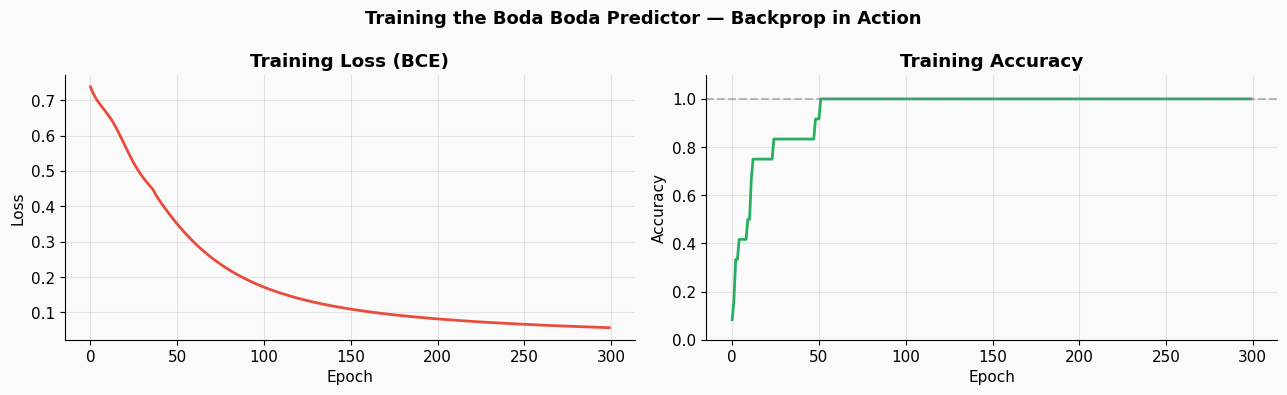

Final loss: 0.0567
Final accuracy: 100%

📖 This is the real thing — backpropagation + gradient descent, from scratch.
   Every epoch: forward pass, chain rule backward, weight update.
   No PyTorch, no TensorFlow. Just calculus.


In [15]:
# ─────────────────────────────────────────────────────────────────
# FULL TRAINING LOOP — WATCH THE NETWORK LEARN
# We'll train on a small dataset and watch the loss fall
# ─────────────────────────────────────────────────────────────────

np.random.seed(42)

# Boda boda dataset: [distance, traffic] → on-time (1) or late (0)
X_data = np.array([
    [2.0, 0.2], [3.0, 0.3], [1.5, 0.1], [4.0, 0.2],   # on time
    [7.0, 0.8], [8.0, 0.9], [6.5, 0.7], [9.0, 0.85],  # late
    [3.5, 0.6], [5.0, 0.5], [4.5, 0.7], [2.5, 0.8],   # mixed
])
y_data = np.array([1,1,1,1,  0,0,0,0,  1,0,0,1])

# Normalise features
X_data = (X_data - X_data.mean(axis=0)) / X_data.std(axis=0)

# Reinitialise weights
np.random.seed(7)
W1 = np.random.randn(4, 2) * 0.3
b1 = np.zeros(4)
W2 = np.random.randn(1, 4) * 0.3
b2 = np.zeros(1)
lr = 0.1

loss_history = []
acc_history  = []

for epoch in range(300):
    epoch_loss = 0
    correct = 0

    for xi, yi in zip(X_data, y_data):
        # Forward
        z1_ = W1 @ xi + b1
        a1_ = relu(z1_)
        z2_ = W2 @ a1_ + b2
        a2_ = sigmoid(z2_)
        l   = bce_loss(a2_, yi)
        epoch_loss += l[0]
        correct    += int((a2_[0] > 0.5) == yi)

        # Backward
        dL_da2_ = a2_ - yi
        da2_dz2_= a2_ * (1 - a2_)
        dL_dz2_ = dL_da2_ * da2_dz2_
        dL_dW2_ = np.outer(dL_dz2_, a1_)
        dL_db2_ = dL_dz2_
        dL_da1_ = W2.T @ dL_dz2_
        dL_dz1_ = dL_da1_ * relu_grad(z1_)
        dL_dW1_ = np.outer(dL_dz1_, xi)
        dL_db1_ = dL_dz1_

        # Update
        W1 -= lr * dL_dW1_
        b1 -= lr * dL_db1_
        W2 -= lr * dL_dW2_
        b2 -= lr * dL_db2_

    loss_history.append(epoch_loss / len(X_data))
    acc_history.append(correct / len(X_data))

# ── Plot training curves ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Training the Boda Boda Predictor — Backprop in Action",
             fontsize=13, fontweight='bold')

axes[0].plot(loss_history, '#E74C3C', lw=2)
axes[0].set_title("Training Loss (BCE)", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(acc_history, '#27AE60', lw=2)
axes[1].set_title("Training Accuracy", fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].axhline(1.0, color='grey', linestyle='--', alpha=0.5)
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Final loss: {loss_history[-1]:.4f}")
print(f"Final accuracy: {acc_history[-1]*100:.0f}%")
print()
print("📖 This is the real thing — backpropagation + gradient descent, from scratch.")
print("   Every epoch: forward pass, chain rule backward, weight update.")
print("   No PyTorch, no TensorFlow. Just calculus.")

---
# PART 7 — Gradient Descent Under the Hood

---

## 7.1 The Weight Update Rule — What Is It Really Doing?

We've been writing:

$$w \leftarrow w - \eta \cdot \frac{\partial L}{\partial w}$$

Let's unpack every symbol:

- **w**: the current weight — a single number we're trying to improve
- **η** (eta): the **learning rate** — controls how big a step we take. Too large → overshoot the minimum. Too small → take forever to get there.
- **∂L/∂w**: the partial derivative of loss with respect to this weight — tells us the slope of the loss surface here
- **The minus sign**: we move *opposite* to the gradient, because gradient points uphill and we want to go downhill

---

## 7.2 The Geometry: The Loss Landscape

Imagine plotting your loss L as a function of all your model's weights. The resulting shape is called the **loss landscape**.

For a model with 2 weights, this is a 3D surface you can visualise. For GPT-4 with 1.8 trillion parameters, this is a 1.8-trillion-dimensional surface — impossible to visualise but governed by the same mathematics.

**Gradient descent is a ball rolling downhill** on this surface.

Key geometric features of the landscape:

- **Global minimum**: the lowest point — where loss is smallest overall
- **Local minimum**: a valley that isn't the lowest point overall — gradient descent can get stuck here
- **Saddle point**: flat in some directions, curved in others — gradient is zero but it's not a minimum
- **Plateau**: a very flat region where gradients are tiny and learning slows dramatically

---

## 7.3 Why Deep Networks Don't Get Stuck (Usually)

Early in the history of deep learning, researchers worried that local minima would make neural networks untrainable. A loss landscape with millions of dimensions might have millions of local traps.

What we've learned empirically and theoretically:

1. **Most local minima in high dimensions are actually good minima** — they have similar loss to the global minimum
2. **Saddle points are more common than true local minima** in high-dimensional spaces
3. **SGD noise actually helps** — the random sampling means the ball bounces around and doesn't settle in shallow traps

This is still an active area of research at frontier labs.

---

## 7.4 Variants of Gradient Descent

| Variant | Gradient computed using | Update frequency | Notes |
|:--------|:-----------------------:|:----------------:|:------|
| **Batch GD** | Entire dataset | Once per epoch | Stable but slow for large datasets |
| **SGD** | One random example | Once per example | Noisy but fast; noise helps escape traps |
| **Mini-batch SGD** | k examples (e.g. 32, 256) | Once per batch | The standard in practice |
| **Adam** | Adaptive per-parameter lr | Once per batch | Most common in deep learning |

Adam (Adaptive Moment Estimation) is essentially mini-batch SGD with two improvements: it tracks momentum (like a ball that builds speed going downhill) and adapts the learning rate per parameter. The calculus is the same — just smarter averaging.

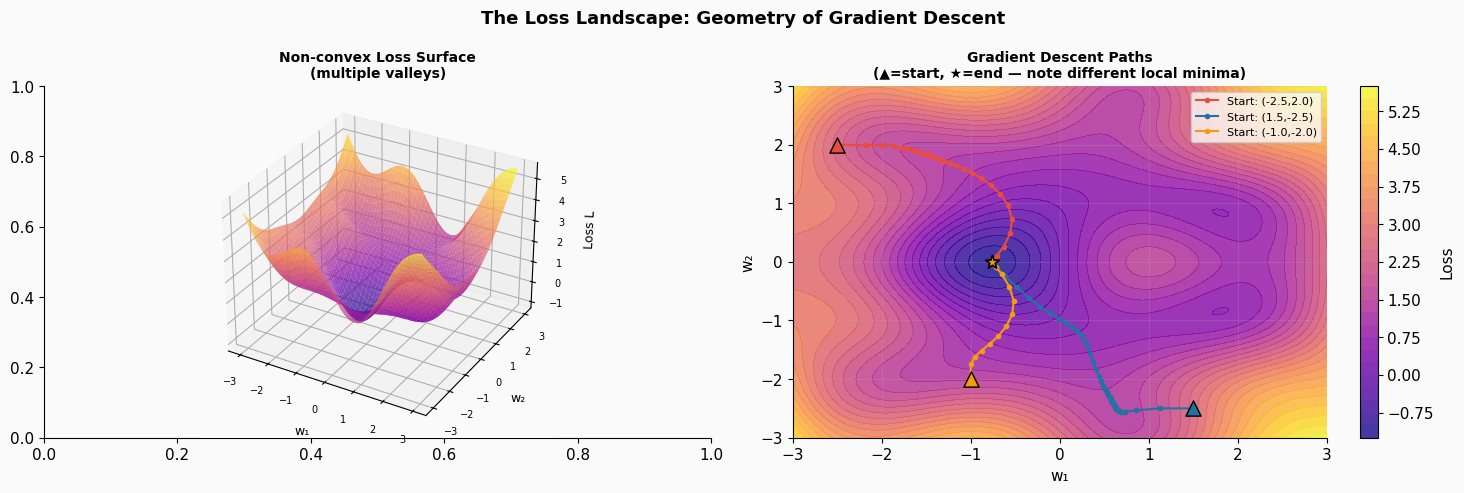

📖 Each path finds a different local minimum — gradient descent is path-dependent.
   In real neural networks, the sheer dimensionality (millions of weights) means
   most minima are roughly equivalent in loss quality.


In [16]:
# ─────────────────────────────────────────────────────────────────
# PART 7: THE LOSS LANDSCAPE — GEOMETRY OF GRADIENT DESCENT
# ─────────────────────────────────────────────────────────────────

# A non-convex 2D loss landscape with multiple minima
def loss_landscape(w1, w2):
    return (np.sin(2*w1) * np.cos(w2) + 0.3*(w1**2 + w2**2)
            + 0.5*np.cos(3*w2) * np.sin(w1))

def grad_landscape(w1, w2, h=1e-5):
    dw1 = (loss_landscape(w1+h, w2) - loss_landscape(w1-h, w2)) / (2*h)
    dw2 = (loss_landscape(w1, w2+h) - loss_landscape(w1, w2-h)) / (2*h)
    return dw1, dw2

w1_range = np.linspace(-3, 3, 200)
w2_range = np.linspace(-3, 3, 200)
W1_g, W2_g = np.meshgrid(w1_range, w2_range)
L_g = loss_landscape(W1_g, W2_g)

# Simulate gradient descent from 3 different starting points
starts = [(-2.5, 2.0, '#E74C3C'), (1.5, -2.5, '#2471A3'), (-1.0, -2.0, '#F39C12')]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("The Loss Landscape: Geometry of Gradient Descent",
             fontsize=13, fontweight='bold')

# ── Left: 3D surface ─────────────────────────────────────────────
ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot_surface(W1_g, W2_g, L_g, cmap='plasma', alpha=0.7, linewidth=0)
ax3d.set_xlabel('w₁', fontsize=9)
ax3d.set_ylabel('w₂', fontsize=9)
ax3d.set_zlabel('Loss L', fontsize=9)
ax3d.set_title('Non-convex Loss Surface\n(multiple valleys)', fontsize=10, fontweight='bold')
ax3d.tick_params(labelsize=7)

# ── Right: contour + gradient descent paths ──────────────────────
ax2d = axes[1]
cp = ax2d.contourf(W1_g, W2_g, L_g, levels=30, cmap='plasma', alpha=0.8)
plt.colorbar(cp, ax=ax2d, label='Loss')

for (start_w1, start_w2, col) in starts:
    path_w1, path_w2 = [start_w1], [start_w2]
    w1_c, w2_c = start_w1, start_w2
    lr_gd = 0.15
    for _ in range(60):
        g1, g2 = grad_landscape(w1_c, w2_c)
        w1_c -= lr_gd * g1
        w2_c -= lr_gd * g2
        path_w1.append(w1_c)
        path_w2.append(w2_c)
    ax2d.plot(path_w1, path_w2, '-o', color=col, markersize=3,
              lw=1.5, label=f'Start: ({start_w1},{start_w2})')
    ax2d.scatter([path_w1[0]], [path_w2[0]], color=col, s=120,
                 zorder=6, marker='^', edgecolors='black')
    ax2d.scatter([path_w1[-1]], [path_w2[-1]], color=col, s=100,
                 zorder=6, marker='*', edgecolors='black')

ax2d.set_xlabel('w₁', fontsize=11)
ax2d.set_ylabel('w₂', fontsize=11)
ax2d.set_title('Gradient Descent Paths\n(▲=start, ★=end — note different local minima)',
               fontsize=10, fontweight='bold')
ax2d.legend(fontsize=8)
ax2d.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('loss_landscape.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 Each path finds a different local minimum — gradient descent is path-dependent.")
print("   In real neural networks, the sheer dimensionality (millions of weights) means")
print("   most minima are roughly equivalent in loss quality.")

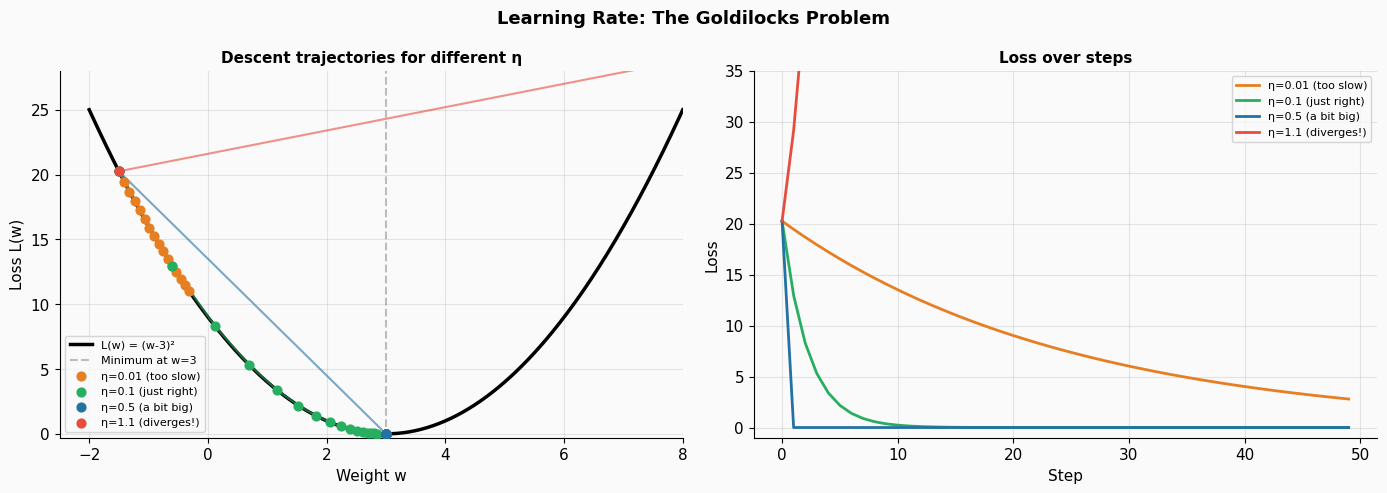

📖 Learning rate tuning is one of the most impactful hyperparameters.
   Too small → painfully slow convergence.
   Too large → oscillation or divergence.
   Modern optimisers (Adam, AdamW) adapt the learning rate automatically.


In [17]:
# ─────────────────────────────────────────────────────────────────
# COMPARING LEARNING RATES — THE GOLDILOCKS PROBLEM
# ─────────────────────────────────────────────────────────────────

# Simple 1D convex loss: L(w) = (w - 3)²
def loss_1d(w):  return (w - 3)**2
def grad_1d(w):  return 2*(w - 3)

lr_values = [0.01, 0.1, 0.5, 1.1]   # too slow, good, good, too fast
labels    = ['η=0.01 (too slow)', 'η=0.1 (just right)', 'η=0.5 (a bit big)', 'η=1.1 (diverges!)']
colours   = ['#E67E22', '#27AE60', '#2471A3', '#E74C3C']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Learning Rate: The Goldilocks Problem", fontsize=13, fontweight='bold')

# Left: trajectories on the loss landscape
w_range = np.linspace(-2, 8, 300)
axes[0].plot(w_range, loss_1d(w_range), 'k-', lw=2.5, label='L(w) = (w-3)²')
axes[0].axvline(3, color='grey', linestyle='--', alpha=0.5, label='Minimum at w=3')

for lr_v, label, col in zip(lr_values, labels, colours):
    w_curr = -1.5
    ws = [w_curr]
    for _ in range(15):
        w_curr = w_curr - lr_v * grad_1d(w_curr)
        ws.append(w_curr)
        if abs(w_curr) > 15: break
    axes[0].scatter(ws, [loss_1d(w) for w in ws], color=col, s=40,
                    zorder=5, label=label)
    axes[0].plot(ws, [loss_1d(w) for w in ws], color=col, lw=1.5, alpha=0.6)

axes[0].set_xlim(-2.5, 8)
axes[0].set_ylim(-0.3, 28)
axes[0].set_xlabel('Weight w', fontsize=11)
axes[0].set_ylabel('Loss L(w)', fontsize=11)
axes[0].set_title('Descent trajectories for different η', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: loss over steps for each lr
for lr_v, label, col in zip(lr_values, labels, colours):
    w_curr = -1.5
    losses = []
    for _ in range(50):
        l = loss_1d(w_curr)
        losses.append(min(l, 50))   # clip for visualisation
        w_curr = w_curr - lr_v * grad_1d(w_curr)
    axes[1].plot(losses, color=col, lw=2, label=label)

axes[1].set_xlabel('Step', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Loss over steps', fontsize=11, fontweight='bold')
axes[1].set_ylim(-1, 35)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_rates.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 Learning rate tuning is one of the most impactful hyperparameters.")
print("   Too small → painfully slow convergence.")
print("   Too large → oscillation or divergence.")
print("   Modern optimisers (Adam, AdamW) adapt the learning rate automatically.")

---
# PART 8 — Exercises

---

## 8.1 Conceptual Exercises

**Exercise A — The Chain Rule by Hand**

A recipe recommender scores dishes as: $S = \sigma(w \cdot \text{spice} + b)$ where $\sigma$ is sigmoid.

Given: spice=0.8, w=1.5, b=0.2, true label y=1 (user liked spicy food)
Loss: $L = -\log(S)$ (cross-entropy for positive label)

1. Forward pass: compute the score S and loss L
2. Backward: what is ∂L/∂w? (hint: chain through ∂L/∂S → ∂S/∂z → ∂z/∂w)
3. If η=0.1, what are the updated w and b?

**Exercise B — Dead Neurons**

A ReLU neuron receives z = W·x + b = -2.5 on every training example.

1. What is ReLU(-2.5)?
2. What is the gradient of ReLU at z = -2.5?
3. Will this neuron's weights ever be updated? Why?
4. What initialisation or architectural trick could prevent this?

**Exercise C — Gradient Magnitudes**

You have a 10-layer network. Each layer multiplies the gradient by a factor of 0.4 (sigmoid-like saturation).

1. What is the magnitude of the gradient at layer 1, if it starts at 1.0 at layer 10?
2. And if each layer multiplies by 2.5 instead?
3. What problem does each scenario cause, and what fixes each one?

---

In [18]:
# ── Exercise A: Recipe Recommender Chain Rule ─────────────────────
spice = 0.8
w_r, b_r = 1.5, 0.2
y_r = 1.0
lr_r = 0.1

# Forward pass
z_r   = None   # w*spice + b
S_r   = None   # sigmoid(z)
L_r   = None   # -log(S)

# Chain rule: L = -log(σ(z))  →  ∂L/∂w = (S - y) * spice  (for BCE + sigmoid)
dL_dw_r = None
dL_db_r = None

# Updated weights
w_new_r = None
b_new_r = None

# Numerical verification
def fwd_r(w_, b_): return -np.log(sigmoid(w_*spice + b_) + 1e-9)
h = 1e-6
num_dw_r = (fwd_r(w_r+h, b_r) - fwd_r(w_r, b_r)) / h
num_db_r = (fwd_r(w_r, b_r+h) - fwd_r(w_r, b_r)) / h

print("Exercise A — Recipe Recommender")
print(f"Numerical ∂L/∂w = {num_dw_r:.4f}")
print(f"Numerical ∂L/∂b = {num_db_r:.4f}")
if dL_dw_r is not None:
    print(f"Your ∂L/∂w = {dL_dw_r:.4f}  {'✅' if abs(dL_dw_r-num_dw_r)<1e-2 else '❌'}")
    print(f"Your ∂L/∂b = {dL_db_r:.4f}  {'✅' if abs(dL_db_r-num_db_r)<1e-2 else '❌'}")
else:
    print("Fill in the None values to solve!")

print()
print("--- SOLUTION ---")
# z = 1.5*0.8 + 0.2 = 1.4
# S = sigmoid(1.4) ≈ 0.8022
# L = -log(0.8022) ≈ 0.2204
# dL/dw = (S - y) * spice = (0.8022-1)*0.8 ≈ -0.1582
# dL/db = (S - y) = -0.1978
# w_new = 1.5 - 0.1*(-0.1582) = 1.5158
# b_new = 0.2 - 0.1*(-0.1978) = 0.2198

Exercise A — Recipe Recommender
Numerical ∂L/∂w = -0.1583
Numerical ∂L/∂b = -0.1978
Fill in the None values to solve!

--- SOLUTION ---


Exercise B — Dead Neurons
  ReLU(-2.5) = 0
  ReLU'(-2.5) = 0
  This neuron's weight gradient = upstream_grad * 0 = 0
  → Weights NEVER update. The neuron is permanently dead.
  Fix: use Leaky ReLU, careful weight init, or batch normalisation

Exercise C — Vanishing vs Exploding Gradients
  Starting gradient: 1.0 at layer 10
  With factor 0.4 per layer: gradient at layer 1 = 0.000105  ← VANISHING
  With factor 2.5 per layer: gradient at layer 1 = 9536.7  ← EXPLODING

  Vanishing gradients → early layers don't learn. Fix: ReLU, ResNets, careful init.
  Exploding gradients → weight updates are massive, training diverges. Fix: gradient clipping.


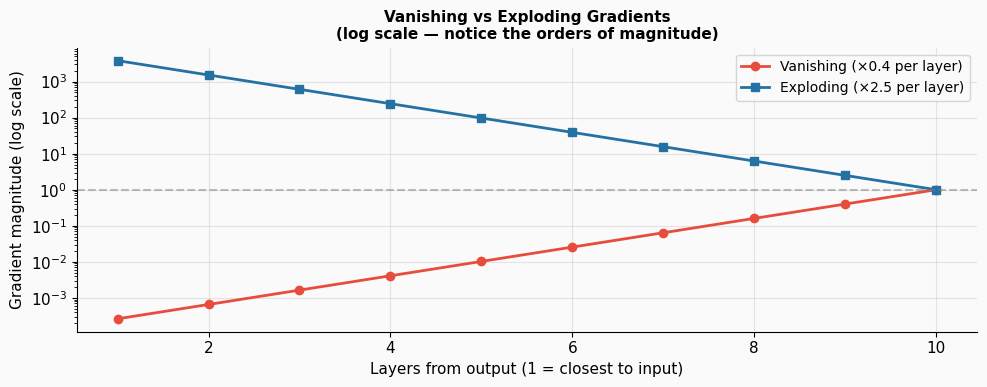

In [19]:
# ── Exercise B & C: Dead neurons & Vanishing/Exploding Gradients ──

print("Exercise B — Dead Neurons")
z_dead = -2.5
print(f"  ReLU(-2.5) = {max(0, z_dead)}")
print(f"  ReLU'(-2.5) = {int(z_dead > 0)}")
print("  This neuron's weight gradient = upstream_grad * 0 = 0")
print("  → Weights NEVER update. The neuron is permanently dead.")
print("  Fix: use Leaky ReLU, careful weight init, or batch normalisation")
print()

print("Exercise C — Vanishing vs Exploding Gradients")
n_layers = 10
factor_vanish = 0.4
factor_explode = 2.5

grad_vanish  = 1.0 * (factor_vanish ** n_layers)
grad_explode = 1.0 * (factor_explode ** n_layers)

print(f"  Starting gradient: 1.0 at layer 10")
print(f"  With factor {factor_vanish} per layer: gradient at layer 1 = {grad_vanish:.6f}  ← VANISHING")
print(f"  With factor {factor_explode} per layer: gradient at layer 1 = {grad_explode:.1f}  ← EXPLODING")
print()
print("  Vanishing gradients → early layers don't learn. Fix: ReLU, ResNets, careful init.")
print("  Exploding gradients → weight updates are massive, training diverges. Fix: gradient clipping.")

# Visualise the gradient magnitude decay / explosion
layers = np.arange(n_layers, 0, -1)
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(layers, [factor_vanish**i for i in range(n_layers)], 'o-',
            color='#E74C3C', lw=2, label=f'Vanishing (×{factor_vanish} per layer)')
ax.semilogy(layers, [factor_explode**i for i in range(n_layers)], 's-',
            color='#2471A3', lw=2, label=f'Exploding (×{factor_explode} per layer)')
ax.axhline(1.0, color='grey', linestyle='--', alpha=0.5)
ax.set_xlabel('Layers from output (1 = closest to input)', fontsize=11)
ax.set_ylabel('Gradient magnitude (log scale)', fontsize=11)
ax.set_title('Vanishing vs Exploding Gradients\n(log scale — notice the orders of magnitude)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('vanishing_exploding.png', dpi=120, bbox_inches='tight')
plt.show()

CHALLENGE EXERCISE — Adam Optimizer from Scratch

Adam maintains two moving averages for each parameter:
  m = β₁ * m + (1-β₁) * g      (1st moment: mean of gradients, momentum)
  v = β₂ * v + (1-β₂) * g²     (2nd moment: mean of squared gradients)
  m̂ = m / (1 - β₁ᵗ)            (bias correction, important early in training)
  v̂ = v / (1 - β₂ᵗ)
  w = w - η * m̂ / (√v̂ + ε)    (update: smaller steps where gradients are noisy)



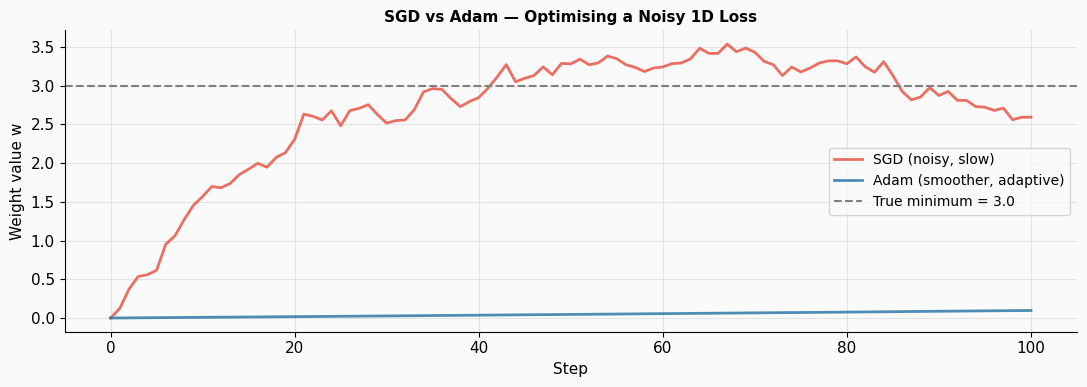

SGD final w = 2.592   (target: 3.0)
Adam final w = 0.097  (target: 3.0)


In [20]:
# ── Challenge Exercise: Implement Adam from scratch ───────────────

print("CHALLENGE EXERCISE — Adam Optimizer from Scratch")
print()
print("Adam maintains two moving averages for each parameter:")
print("  m = β₁ * m + (1-β₁) * g      (1st moment: mean of gradients, momentum)")
print("  v = β₂ * v + (1-β₂) * g²     (2nd moment: mean of squared gradients)")
print("  m̂ = m / (1 - β₁ᵗ)            (bias correction, important early in training)")
print("  v̂ = v / (1 - β₂ᵗ)")
print("  w = w - η * m̂ / (√v̂ + ε)    (update: smaller steps where gradients are noisy)")
print()

def adam_step(w, g, m, v, t, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    """
    One Adam update step.
    w: current weight
    g: current gradient
    m, v: running moment estimates
    t: current timestep (for bias correction)
    """
    m_new = beta1 * m + (1 - beta1) * g          # update 1st moment
    v_new = beta2 * v + (1 - beta2) * g**2       # update 2nd moment
    m_hat = m_new / (1 - beta1**t)               # bias-corrected
    v_hat = v_new / (1 - beta2**t)
    w_new = w - lr * m_hat / (np.sqrt(v_hat) + eps)   # weight update
    return w_new, m_new, v_new

# Compare SGD vs Adam on a noisy gradient landscape
np.random.seed(0)
n_steps = 100
true_minimum = 3.0

# SGD
w_sgd = 0.0;  lr_sgd = 0.05
path_sgd = [w_sgd]
for t in range(1, n_steps+1):
    g = 2*(w_sgd - true_minimum) + np.random.randn()*2.0   # gradient + noise
    w_sgd -= lr_sgd * g
    path_sgd.append(w_sgd)

# Adam
w_adam = 0.0;  m_a, v_a = 0.0, 0.0
path_adam = [w_adam]
for t in range(1, n_steps+1):
    g = 2*(w_adam - true_minimum) + np.random.randn()*2.0
    w_adam, m_a, v_a = adam_step(w_adam, g, m_a, v_a, t)
    path_adam.append(w_adam)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(path_sgd,  '#E74C3C', lw=2, label='SGD (noisy, slow)', alpha=0.8)
ax.plot(path_adam, '#2471A3', lw=2, label='Adam (smoother, adaptive)', alpha=0.8)
ax.axhline(true_minimum, color='grey', linestyle='--', lw=1.5, label=f'True minimum = {true_minimum}')
ax.set_xlabel('Step', fontsize=11)
ax.set_ylabel('Weight value w', fontsize=11)
ax.set_title('SGD vs Adam — Optimising a Noisy 1D Loss', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sgd_vs_adam.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"SGD final w = {path_sgd[-1]:.3f}   (target: {true_minimum})")
print(f"Adam final w = {path_adam[-1]:.3f}  (target: {true_minimum})")

---
# PART 9 — Your Summary Notes

---

This section is written to be **copied into your personal notebook**.

---

## 📝 Note 1: Derivatives

The **derivative** f'(x) of a function at a point x is the instantaneous rate of change — the slope of the tangent line at that point. Formally, it is the limit of (f(x+h) - f(x)) / h as h → 0. In machine learning, the derivative of the loss with respect to a weight tells us: if I nudge this weight slightly, does the loss go up or down? A positive derivative → decrease the weight. A negative derivative → increase it. A zero derivative → the weight has no effect here. The key derivatives in ML are: d(xⁿ)/dx = n·xⁿ⁻¹, d(eˣ)/dx = eˣ, d(ln x)/dx = 1/x, d(sigmoid)/dx = σ(1-σ), d(ReLU)/dx = 1 if x>0 else 0.

**TL;DR:** *A derivative is a slope. Gradient descent follows slopes downhill.*

---

## 📝 Note 2: Partial Derivatives and the Gradient

When a function takes multiple inputs (like all neural network loss functions do), a **partial derivative** ∂f/∂xᵢ measures how f changes when xᵢ varies, holding all other inputs constant. The **gradient** ∇f is the vector of all partial derivatives — it points in the direction of steepest ascent. Gradient descent subtracts a small multiple η (the learning rate) of the gradient from the current weights: w ← w - η·∇L. This moves weights in the direction that decreases loss most quickly. The learning rate η controls step size — too large causes oscillation or divergence; too small causes painfully slow learning.

**TL;DR:** *The gradient is the "which direction is uphill?" answer. We go the opposite way.*

---

## 📝 Note 3: The Chain Rule

The **chain rule** is the engine of backpropagation. For composed functions y = f(g(x)), it states: dy/dx = (dy/dg) · (dg/dx) — multiply the derivatives through the chain. A neural network is a deeply composed function: input → linear → activation → linear → activation → loss. To compute how the loss changes with respect to an early weight w₁, the chain rule multiplies the local gradients at every layer between w₁ and the loss. This is **backpropagation**: evaluate the chain rule product, starting from the loss and working backward through the network. The word "backward" refers literally to traversing the computational graph in reverse.

**TL;DR:** *Backpropagation = chain rule, applied layer by layer, from loss to weights.*

---

## 📝 Note 4: Computational Graphs

A **computational graph** represents a mathematical expression as a directed graph where nodes are operations or inputs and edges carry values. Every node computes its output during the forward pass and stores the local gradient for the backward pass. **Backpropagation** traverses the graph in reverse topological order, using the chain rule to multiply local gradients and accumulate them into weight gradients. PyTorch builds this graph dynamically — as Python runs, each tensor operation records itself in the graph. Calling loss.backward() triggers the backward traversal. This is the `autograd` system under the hood.

**TL;DR:** *PyTorch's computation graph is just a representation of nested chain rule applications.*

---

## 📝 Note 5: Jacobians

When a function maps a vector to a vector (as most neural network layers do), the generalisation of the derivative is the **Jacobian matrix** J. Entry J[i,j] is ∂yᵢ/∂xⱼ — how output i changes when input j varies. For a linear layer y = Wx, the Jacobian is simply W itself. For element-wise operations like ReLU, the Jacobian is a diagonal matrix (no cross-coupling between elements). In practice, deep learning frameworks never compute full Jacobians for large layers — instead they use **vector-Jacobian products** (VJPs): given the incoming gradient vector v, compute vᵀJ without materialising J. This is what makes backpropagation scalable to billion-parameter models.

**TL;DR:** *The Jacobian is the derivative for vector functions. In deep learning, it's almost always computed implicitly.*

---

## 📝 Note 6: The Loss Landscape and Gradient Descent Variants

The **loss landscape** is the surface formed by plotting loss as a function of all weights. Gradient descent is a ball rolling downhill on this surface. The landscape can have local minima (valleys), saddle points (flat in some directions), and plateaus (gradients ≈ 0). In high-dimensional spaces, most local minima are as good as the global minimum — this is empirically and theoretically established for modern deep networks. **Batch gradient descent** uses the full dataset per step (stable but slow). **SGD** uses one example (fast and noisy — noise helps escape traps). **Mini-batch SGD** (batches of 32–512) is the standard. **Adam** extends SGD with momentum and adaptive per-parameter learning rates — it is the default optimiser in frontier deep learning.

**TL;DR:** *Gradient descent rolls downhill. Adam rolls faster and smarter.*

---

## 📝 Note 7: The Full Calculus Map of Backpropagation

```
INPUT x
   │
   ▼  z = W·x + b
LINEAR TRANSFORM  ──── dz/dW = xᵀ,  dz/dx = W,  dz/db = 1
   │
   ▼  a = ReLU(z)
ACTIVATION  ──────────  da/dz = diag(1[z>0])   (diagonal Jacobian)
   │
   ▼  [repeat for each layer]
   │
   ▼  L = loss(ŷ, y)
LOSS  ────────────────  dL/dŷ = (ŷ - y) for MSE or BCE+sigmoid
   │
   ▼  BACKWARD (chain rule — multiply from here back to inputs)
dL/dW = (dL/da)(da/dz)(dz/dW)   ← matrix form: δ · xᵀ
dL/db = (dL/da)(da/dz)           ← just δ
dL/dx = (dL/da)(da/dz)(dz/dx)   ← Wᵀ · δ  (for propagating to prev layer)
   │
   ▼  WEIGHT UPDATE
W ← W - η · dL/dW
b ← b - η · dL/db
   │
   ▼
CONVERGED WEIGHTS  ─── the model has learned
```

In [21]:
# ─────────────────────────────────────────────────────────────────
# FINAL SUMMARY PRINTOUT
# ─────────────────────────────────────────────────────────────────

print("=" * 65)
print("CALCULUS FOR BACKPROPAGATION — COMPLETE")
print("=" * 65)

checklist = [
    ("Derivatives",
     "Instantaneous rate of change. The slope of the curve at a point."),
    ("Partial Derivatives",
     "Rate of change w.r.t. one variable, others held constant."),
    ("The Gradient",
     "Vector of all partial derivatives. Points uphill. We go down."),
    ("The Chain Rule",
     "Derivative of composed functions = product of local derivatives."),
    ("Computational Graphs",
     "Directed graphs where each node stores a forward value + backward gradient."),
    ("Backpropagation",
     "Reverse traversal of the computational graph using the chain rule."),
    ("Jacobians",
     "The full derivative for vector-to-vector functions. Usually implicit in practice."),
    ("Gradient Descent Variants",
     "SGD, mini-batch, Adam — the same calculus, with smarter step strategies."),
]

for topic, detail in checklist:
    print(f"\n  ✅ {topic}")
    print(f"     {detail}")

print()
print("=" * 65)
print("WHAT COMES NEXT")
print("=" * 65)
print("""
  You now have the full calculus foundation. The next notebooks:
  
  🧠  Attention Mechanisms from Scratch
      (The Q/K/V dot products and softmax — all this calculus, scaled up)
  
  🧠  Optimisers Deep Dive
      (Adam, AdamW, schedule-free — the exact moment equations)

  🧠  Scaling Laws & Compute
      (How Chinchilla results are derived. Loss as a function of N and D)

  🧠  Regularisation & Generalisation Theory
      (Weight decay as L2 regularisation, the PAC learning framework)
""")

CALCULUS FOR BACKPROPAGATION — COMPLETE

  ✅ Derivatives
     Instantaneous rate of change. The slope of the curve at a point.

  ✅ Partial Derivatives
     Rate of change w.r.t. one variable, others held constant.

  ✅ The Gradient
     Vector of all partial derivatives. Points uphill. We go down.

  ✅ The Chain Rule
     Derivative of composed functions = product of local derivatives.

  ✅ Computational Graphs
     Directed graphs where each node stores a forward value + backward gradient.

  ✅ Backpropagation
     Reverse traversal of the computational graph using the chain rule.

  ✅ Jacobians
     The full derivative for vector-to-vector functions. Usually implicit in practice.

  ✅ Gradient Descent Variants
     SGD, mini-batch, Adam — the same calculus, with smarter step strategies.

WHAT COMES NEXT

  You now have the full calculus foundation. The next notebooks:
  
  🧠  Attention Mechanisms from Scratch
      (The Q/K/V dot products and softmax — all this calculus, scaled up)
